# BPH-7009 — Analyse de signaux — Devoir 2

<a id="0"></a>
## 0. Préambule

### 0.1 Imports et style

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.special import erf
from scipy.optimize import curve_fit

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#86b6ef", "#70a8eb", "#599be8", "#458ce1", "#327ed9", "#2974d0",
       "#266ec5", "#2365b7", "#1d59a4", "#174d91", "#12417e", "#0d366b"]
GRIS = "#52514e"

def seq(k):
    """
    k couleurs ordonnées, du bleu clair au bleu foncé.
    """

    indices = np.linspace(0, len(SEQ) - 1, k).round().astype(int)
    
    return [SEQ[i] for i in indices]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRIS,
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": True,
    "legend.fontsize": 8,
    "lines.linewidth": 2,
    "lines.markersize": 4,
    "image.cmap": "magma",
    "figure.autolayout": True,
})


### 0.2 Géométries

Toutes les parois sont réfléchissantes.

In [2]:
def _reflechir(x, a, b):
    """
    Replie x dans [a, b] par réflexions successives.
    """

    p = 2*(b - a)
    y = np.mod(x - a, p)

    return a + np.where(y > b - a, p - y, y)


class Plan:
    """
    Plan libre, sans paroi. L ne fixe que l'étendue du tirage initial.
    exact = True : le repliement peut s'appliquer d'un coup au chemin non replié,
    ce qui autorise une simulation par blocs vectorisés plutôt qu'en boucle.
    """

    exact = True

    def __init__(self, L=10.0):
        self.L = L

    def tirage(self, rng, n):
        return rng.uniform(-self.L/2, self.L/2, (n, 2))

    def replier(self, r):
        return r

    def limites(self, r, r0):
        return self.replier(r)


class Boite(Plan):
    """
    Boîte carrée L x L à parois réfléchissantes.
    """

    def replier(self, r):
        x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        y = _reflechir(r[..., 1], -self.L/2, self.L/2)

        return np.stack([x, y], -1)


class Disque:
    """
    Confinement circulaire de rayon R.
    """

    exact = False

    def __init__(self, R):
        self.R = R

    def tirage(self, rng, n):
        th = rng.uniform(0, 2*np.pi, n)
        u = np.sqrt(rng.uniform(size=n))

        return self.R*np.stack([u*np.cos(th), u*np.sin(th)], 1)

    def limites(self, r, r0):
        d = np.hypot(r[:, 0], r[:, 1])
        facteur = np.where(d > self.R, (2*self.R - d)/np.maximum(d, 1e-12), 1.0)

        return r*facteur[:, None]


class Tube:
    """
    Tube de diamètre d orienté selon x. L=None : longueur infinie.
    """

    exact = True

    def __init__(self, d, L=None):
        self.d = d
        self.L = L

    def tirage(self, rng, n):
        if self.L:
            Lx = self.L
        else:
            Lx = self.d

        x = rng.uniform(-Lx/2, Lx/2, n)
        y = rng.uniform(-self.d/2, self.d/2, n)

        return np.stack([x, y], 1)

    def replier(self, r):
        if self.L:
            x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        else:
            x = r[..., 0]

        y = _reflechir(r[..., 1], -self.d/2, self.d/2)

        return np.stack([x, y], -1)

    def limites(self, r, r0):
        return self.replier(r)


### 0.3 Simulateur de trajectoires

Marche aléatoire gaussienne : $\Delta \mathbf{r} \sim \mathcal{N}(0,\ 2D\,\Delta t)$ par axe.
L'argument `mesure` permet de ne conserver qu'une observable (intensité, comptage) au lieu de
toutes les positions, ce qui rend possibles les très longues simulations de FCS.

In [3]:
def simuler(dom, D, T, dt, n=1, f_immobile=0.0, seed=0, mesure=None, bloc=None):
    """
    n trajectoires browniennes 2D dans le domaine `dom`.

    D : coefficient de diffusion (um^2/s)
    T, dt : durée et pas de temps (s)
    f_immobile : fraction de particules fixes
    mesure : fonction appliquée à un bloc de positions (nb,n,2) -> (nb,...) ;
             si fournie, seules ces valeurs sont conservees
    Retour : t (nt,) et positions (nt,n,2) ou mesures (nt,...)

    Les domaines `exact` sont simulés par blocs vectorisés (somme cumulée des pas
    puis repliement).
    """

    rng = np.random.default_rng(seed)
    nt = int(round(T/dt)) + 1
    mobile = np.arange(n) >= round(f_immobile*n)
    mobile = mobile.astype(float)[:, None]
    pas = np.sqrt(2*D*dt)*mobile
    r = dom.tirage(rng, n)
    u = r.copy()
    sortie = []
    k0 = 0
    bloc = bloc or max(4, int(1e6/n))

    while k0 < nt:
        nb = min(bloc, nt - k0)

        if dom.exact:
            d = pas*rng.standard_normal((nb, n, 2))

            if k0 == 0:
                d[0] = 0.

            np.cumsum(d, 0, out=d)
            d += u
            u = d[-1].copy()
            B = dom.replier(d)
        else:
            B = np.empty((nb, n, 2))

            for j in range(nb):
                if k0 or j:
                    r = dom.limites(r + pas*rng.standard_normal((n, 2)), r)
                B[j] = r

        if mesure is None:
            sortie.append(B)
        else:
            sortie.append(mesure(B))

        k0 += nb

    return np.arange(nt)*dt, np.concatenate(sortie)


def bruit_localisation(R, sigma, seed=1):
    """
    Erreur de localisation : bruit blanc gaussien ajouté à chaque position mesurée.
    """

    return R + np.random.default_rng(seed).normal(0., sigma, R.shape)


### 0.4 Déplacement carré moyen

Estimateur de Michalet (2010) qui utilise tous les déplacements de durée $n\Delta t$ :

$$\overline{\rho}_n = \frac{1}{N_p-n}\sum_{i=1}^{N_p-n}(\vec r_{i+n}-\vec r_i)^2
\tag{M7}$$

où $N_p$ est le nombre de positions de la trajectoire. En présence d'une erreur de localisation
$\sigma$, la courbe s'écrit

$$\rho(t) = \underbrace{4\sigma^2 - \tfrac{4}{3}D\,t_E}_{\text{ordonnée à l'origine } a}
+ \underbrace{4D}_{b}\,t
\tag{M14-15}$$

où $t_E$ est le temps d'exposition de la caméra. Les positions simulées ici sont instantanées
($t_E = 0$), donc $a = 4\sigma^2$. L'ajustement linéaire $\rho = a + bt$ donne

$$D = \frac{b}{4}, \qquad \sigma = \frac{1}{2}\sqrt{a}
\tag{M17-18}$$

Il existe un nombre optimal de points à ajuster, fonction de l'erreur de localisation réduite
$x_\sigma = \sigma^2/(D\Delta t)$ (éq. 20 de l'article), où $E$ désigne la partie entière :

$$p_{\min} = E\!\left(2 + 2{,}7\,x_\sigma^{1/2}\right)
\tag{M30}$$

Si le nombre de points est mal choisi, le $D$ ajusté peut être faux de plusieurs ordres de grandeur.
Comme $x_\sigma$ dépend du résultat, `ajuste_msd` part de $p = 2$ et itère. L'ajustement non pondéré
utilisé ici donne le même $p_{\min}$ et la même erreur minimale que l'ajustement pondéré
(section VI B de l'article).

Les numéros **M**$n$ renvoient aux équations de Michalet (2010), **Y**$n$ à celles de Yu *et al.*
(2021). Les équations sans préfixe sont posées ou dérivées ici.

In [4]:
def msd(R, dt, n_lags=35, frac=0.25, axe=None, par_particule=False):
    """
    MSD(tau). axe=None -> 2D ; axe=0 ou 1 -> une seule dimension.
    frac : décalage maximal, en fraction de la durée totale.
    """

    nt = R.shape[0]
    lag_max = max(2, int(frac*nt))
    lags = np.unique(np.logspace(0, np.log10(lag_max), n_lags).astype(int))

    if axe is None:
        X = R
    else:
        X = R[:, :, axe:axe+1]

    m = np.array([((X[l:] - X[:-l])**2).sum(-1).mean(0) for l in lags])

    if par_particule:
        return lags*dt, m

    return lags*dt, m.mean(1)


def ajuste_msd(tau, m, ndim=2, npts=None):
    """
    Régression linéaire MSD = a + b*tau -> (D, sigma)  [Michalet 2010, éq. 16-18].

    npts=None : le nombre de points suit la règle du nombre optimal
    p_min = E(2 + 2.7 sqrt(x)) (éq. 30), avec x = sigma^2/(D dt) (éq. 20) l'erreur de
    localisation réduite. x dépendant du résultat, on part de p = 2 et on itère.
    """

    dt = tau[0]
    p = npts or 2

    if npts:
        n_iter = 1
    else:
        n_iter = 6

    for _ in range(n_iter):
        b, a = np.polyfit(tau[:p], m[:p], 1)   # pente b, ordonnée à l'origine a
        D, s2 = b/(2*ndim), max(a, 0.)/(2*ndim)

        if npts or D <= 0:
            break

        q = min(int(2 + 2.7*np.sqrt(s2/(D*dt))), len(tau))

        if q == p:
            break

        p = q

    return D, np.sqrt(s2)


def plateau(tau, m, frac=0.4):
    """
    Valeur du plateau de MSD (médiane sur les grands décalages).
    """

    return np.median(m[tau >= frac*tau.max()])


### 0.5 Caméra

Chaque molécule dépose `photons` photons répartis par la PSF gaussienne d'écart-type $s_0$,
intégrée sur la surface de chaque pixel (fonctions erreur), puis on ajoute un fond constant et
un tirage poissonien.

Michalet (2010) donne l'incertitude de localisation d'une molécule isolée à partir du nombre
$N_{ph}$ de photons collectés, puis sa correction lorsque la molécule diffuse pendant le temps de
pose $t_E$ :

$$\sigma_0 = \frac{s_0}{\sqrt{N_{ph}}}
\tag{M2}$$

$$\sigma = \sigma_0\sqrt{1 + \frac{D\,t_E}{s_0^2}}
\tag{M4}$$

$\sigma_0$ est l'incertitude statique et $\sigma$ l'incertitude dynamique. Ce sont des bornes
inférieures : ni le bruit de lecture ni la pixellisation ne sont pris en compte.

In [5]:
class Camera:
    """
    Détecteur : PSF gaussienne, pixels carrés, fond et bruit de Poisson.
    """

    def __init__(self, pixel=0.1, psf=0.13, champ=4.0, photons=600, fond=10):
        self.pixel = pixel
        self.psf = psf
        self.champ = champ
        self.photons = photons
        self.fond = fond
        self.npix = int(round(champ/pixel))
        self.bords = -champ/2 + np.arange(self.npix + 1)*pixel

    def _profil(self, c):
        """
        Fraction de photons de chaque molécule tombant dans chaque pixel (1 axe).
        """

        z = (self.bords[None, :] - c[:, None])/(np.sqrt(2)*self.psf)

        return 0.5*np.diff(erf(z), axis=1)

    def image(self, r, rng=None):
        profil_x = self._profil(r[:, 0])
        profil_y = self._profil(r[:, 1])
        img = self.photons*(profil_y.T @ profil_x) + self.fond
        rng = rng or np.random.default_rng(0)

        return rng.poisson(img).astype(float)

    def film(self, R, seed=0):
        rng = np.random.default_rng(seed)

        return np.array([self.image(r, rng) for r in R])

    def precision(self):
        """
        Incertitude de localisation statique sigma_0 = s_0/sqrt(N), um
        [Michalet 2010, eq. 2].
        """

        return self.psf/np.sqrt(self.photons)

    def precision_dynamique(self, D, t_expo):
        """
        Incertitude en présence de diffusion pendant l'exposition [Michalet 2010, eq. 4].
        """

        return self.precision()*np.sqrt(1 + D*t_expo/self.psf**2)


### 0.6 Laser gaussien et autocorrélation

Le faisceau est gaussien, centré en $\mathbf c$, de rayon $w_0$ à $1/e^2$. Le profil d'excitation,
normalisé au centre :

$$I(\mathbf r) = \exp\!\left(-\,\frac{2\,|\mathbf r - \mathbf c|^2}{w_0^2}\right)$$

La densité est exprimée en émetteurs par surface effective $\pi w_0^2$, ce qui donne
directement $G(0) = 1/N$.

Yu *et al.* (2021) définissent l'autocorrélation

$$G(\tau) = \frac{\langle F(t)F(t+\tau)\rangle}{\langle F(t)\rangle^2} - 1
\tag{Y1}$$

puis son modèle de diffusion, pour un volume d'observation d'extension axiale $z_0$ :

$$G(\tau) = \frac{1}{N}\left(1+\frac{\tau}{\tau_D}\right)^{-1}
\left(1+\frac{\tau}{\tau_D}\frac{w_0^2}{z_0^2}\right)^{-1/2}
\tag{Y2}$$

L'article note ce rayon $r_0$ ; on garde $w_0$ ici pour rester cohérent avec l'énoncé et avec le
code. En 2D, c'est-à-dire pour une diffusion dans une membrane, il suffit de poser $w_0/z_0 = 0$
dans (Y2), ce qui laisse

$$G(\tau) = \frac{G_0}{1+\tau/\tau_D},
\qquad G_0 = \frac{1}{N},
\qquad \tau_D = \frac{w_0^2}{4D}$$

d'où $D = w_0^2/(4\tau_D)$. La moyenne par intervalles logarithmiques de `correlation`
reproduit l'algorithme multi-tau des corrélateurs décrits dans l'article.

`fcs` enchaîne les deux étapes, de la trajectoire à $G(\tau)$. Le signal corrélé est l'intensité
collectée, sans bruit de détection : $G$ est invariante d'échelle, donc **la brillance du
fluorophore n'a aucun effet** tant qu'aucun bruit n'est ajouté. Elle n'est pas un paramètre du
simulateur. Le bruit de détection est traité séparément à la partie D, où il est ajouté
directement sur la corrélation par `bruit_blanc`.

In [6]:
class Faisceau:
    """
    Laser gaussien : renvoie la somme des intensités vues par les molécules.
    """

    def __init__(self, w0=0.2, centre=(0., 0.)):
        self.w0 = w0
        self.centre = np.asarray(centre, float)

    def __call__(self, r):
        d2 = ((r - self.centre)**2).sum(-1)

        return np.exp(-2*d2/self.w0**2).sum(-1)


def n_particules(N_eff, aire, w0):
    """
    Nombre de molécules donnant N_eff émetteurs par surface effective pi*w0^2.
    """

    return max(1, int(round(N_eff*aire/(np.pi*w0**2))))


def _moy_log(tau, g, n_bins):
    """
    Moyenne par intervalles logarithmiques.
    """

    i = np.unique(np.round(np.logspace(0, np.log10(len(tau)), n_bins)).astype(int))
    i = i[i < len(tau)]

    return (np.array([tau[a:b].mean() for a, b in zip(i[:-1], i[1:])]), np.array([g[a:b].mean() for a, b in zip(i[:-1], i[1:])]))


def correlation(F, dt=1., n_bins=45):
    """
    G(tau) = <dF(t) dF(t+tau)> / <F>^2, par FFT puis moyennage logarithmique.
    """

    N = len(F)
    m = F.mean()
    npad = 1 << int(np.ceil(np.log2(2*N)))
    f = np.fft.rfft(F - m, npad)
    c = np.fft.irfft(np.conj(f)*f, npad)[:N]
    denom = np.arange(N, 0, -1)*m**2
    g = (c/denom)[1:]

    return _moy_log(np.arange(1, N)*dt, g, n_bins)


def bruit_blanc(F, fond, seed=0):
    """
    Bruit blanc sur un comptage de photons : coups parasites tires dans une loi
    de Poisson de moyenne `fond` (obscurite du detecteur, lumiere diffusee).

    Un bruit gaussien additif serait ici le mauvais modele : il rendrait le
    comptage negatif, ce qu'un detecteur de photons ne peut pas mesurer. La loi
    de Poisson garde un entier positif. Le tirage est independant d'un bin au
    suivant, donc le bruit reste blanc : il ne contribue qu'a tau = 0.
    """

    return F + np.random.default_rng(seed).poisson(fond, np.shape(F))


def fcs(dom, D, T, dt, n, faisceau, n_rep=1, seed=0, f_immobile=0., cps=2e4,
        bruit=0., seed_bruit=0):
    """
    Autocorrelation G(tau) = <dF(t) dF(t+tau)>/<F>^2 d'une trace de photons,
    moyennee sur n_rep tirages independants.

    cps   : brillance, photons/s pour une molecule au centre du faisceau. Elle
            fixe le nombre de photons par bin, donc le bruit de grenaille.
    bruit : niveau de fond parasite ajoute a la trace, en fraction du nombre
            moyen de photons par bin. Poissonien, donc toujours positif.
    seed_bruit : graine de ce bruit seul. La laisser varier tandis que `seed`
            reste fixe permet de comparer plusieurs niveaux de bruit sur la
            meme trajectoire.

    Retour : tau, G, erreur type sur G, et la trace de photons du dernier tirage.
    """

    G = []

    for k in range(n_rep):
        t, I = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed + k, mesure=faisceau)
        F = np.random.default_rng(seed + k + 7919).poisson(cps*dt*I).astype(float)

        if bruit:
            F = bruit_blanc(F, bruit*F.mean(), seed=seed_bruit + k)

        F = F.astype(float)

        tau, g = correlation(F, dt=dt)
        G.append(g)

    G = np.array(G)

    return tau, G.mean(0), G.std(0)/np.sqrt(max(n_rep - 1, 1)), F


def modele_fcs(tau, G0, tauD):
    return G0/(1 + tau/tauD)


def modele_fcs2(tau, G0, tauD1, tauD2, f):
    terme_rapide = f/(1 + tau/tauD1)
    terme_lent = (1 - f)/(1 + tau/tauD2)

    return G0*(terme_rapide + terme_lent)


def ajuste_fcs(tau, G, w0, p0=None):
    """
    Ajustement du modèle 2D à une composante -> N, tau_D, D.
    """

    p0 = p0 or [max(G[:3].mean(), 1e-6), tau[len(tau)//3]]

    p, _ = curve_fit(modele_fcs, tau, G, maxfev=20000, p0=p0)
    
    return dict(N=1/p[0], tau_D=p[1], D=w0**2/(4*p[1]))

### 0.7 FRAP

`SondeFRAP` éteint définitivement les molécules présentes dans le disque de rayon $R_b$ au premier
pas de temps, puis compte les molécules fluorescentes qui s'y trouvent. Le retour est normalisé par
l'occupation moyenne du disque, de sorte que $F = 1$ avant blanchiment.

Une courbe de FRAP contient deux informations, la cinétique et la
fraction mobile, et un ajustement mono-exponentiel permet d'extraire toutes les deux.
C'est ce que fait `ajuste_frap` :

$$F(t) = A\left(1 - e^{-t/\tau}\right),
\qquad t_{1/2} = \tau\ln 2$$

$A$ est le plateau, donc la fraction mobile, et $t_{1/2}$ le demi-temps de retour. 

Dans une boîte fermée de côté $L$, le plateau ne peut pas atteindre 1 : les molécules blanchies se
diluent dans toute la boîte au lieu de disparaître. Comme il y a un nombre fini de particules dans la boîte,
la fluorescence maximale est limitée par le nombre de particules non-blanchies,

$$F_\infty = \left(1 - \frac{\pi R_b^2}{L^2}\right)\left(1 - f_{\rm immobile}\right).$$

C'est cette valeur, et non 1, qui sert de référence dans les graphiques.

In [7]:
class SondeFRAP:
    """
    Blanchit le disque de rayon Rb au premier appel, puis compte
    (molécules fluorescentes dans le disque, molécules totales dans le disque).
    """

    def __init__(self, Rb):
        self.Rb = Rb
        self.fluo = None

    def __call__(self, r):
        dedans = (r**2).sum(-1) < self.Rb**2

        if self.fluo is None:
            self.fluo = ~dedans[0]

        return np.stack([(self.fluo & dedans).sum(-1), dedans.sum(-1)], -1)


def frap(dom, D, Rb, T, dt, n, f_immobile=0., n_rep=1, seed=0):
    """
    Courbe de retour de fluorescence, normalisée à 1 avant blanchiment.
    """

    F = []

    for k in range(n_rep):
        sonde = SondeFRAP(Rb)
        t, c = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed + k, mesure=sonde)
        F.append(c[:, 0]/c[:, 1].mean())

    return t, np.mean(F, 0)


def modele_frap(t, A, tau):
    """
    Retour mono-exponentiel. A est le plateau (fraction mobile), tau le temps
    caracteristique. Description empirique de la cinetique : ne donne pas de D.
    """

    return A*(1 - np.exp(-t/tau))


def ajuste_frap(t, F):
    """
    Ajustement mono-exponentiel -> fraction mobile et t_1/2 (Kenworthy 2023).
    Aucun D n'est estime : l'exponentielle n'est pas la solution du probleme de
    diffusion, et le vrai retour en 2D a une queue en 1/t.
    """

    A0 = F[int(0.8*len(F)):].mean()
    lisse = np.convolve(F, np.ones(11)/11, "same")
    i = np.argmax(lisse >= A0/2)
    tau0 = max(t[i], t[1])/np.log(2)
    p, _ = curve_fit(modele_frap, t[1:], F[1:], p0=[A0, tau0],
                     bounds=([0., 1e-6], [2., np.inf]), maxfev=20000)

    return dict(mobile=p[0], tau=p[1], t_demi=p[1]*np.log(2))


def plateau_attendu(Rb, L, f_immobile=0.):
    """
    Plateau theorique en boite fermee : les molecules blanchies se diluent dans
    toute la boite, donc F_infini < 1 des que le disque n'est pas negligeable.
    """

    return (1 - np.pi*Rb**2/L**2)*(1 - f_immobile)


<a id="1"></a>
# 1. Simulateur 1 — MSD d'une particule unique

Paramètres de l'expérience : durée totale $T$, intervalle entre deux détections $\Delta t$,
précision de localisation $\sigma$, coefficient de diffusion $D$, et géométrie du confinement.

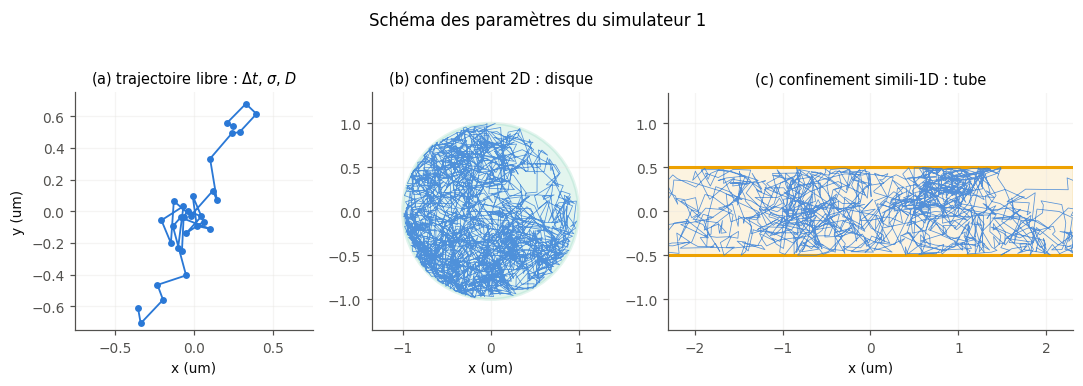

In [8]:
# --- paramètres du simulateur 1 -------------------------------
D1 = 1.0          # coefficient de diffusion, um^2/s
DT1 = 0.01        # intervalle entre détections, s (100 images/s)
T1 = 10.0         # durée totale, s
SIG1 = 0.03       # précision de localisation, um
R_DISQUE = 1.0    # rayon du disque de confinement, um (cercle de 2 um de diamètre)
D_TUBE = 1.0      # diamètre du tube de confinement, um

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), width_ratios=[1, 1, 1.7])
BOITE = dict(fc="white", ec="none", alpha=.85, pad=1.5)


# (a) paramètres d'une trajectoire
t, R = simuler(Plan(1.), D1, 0.3, DT1, n=1, seed=10)
xy = R[:, 0] - R[:, 0].mean(0)

ax[0].plot(*xy.T, "-o", color=CAT[0], ms=3.5, lw=1.2)
ax[0].set_xlim(-.75, .75)
ax[0].set_ylim(-.75, .75)
ax[0].set_title("(a) trajectoire libre : $\\Delta t$, $\\sigma$, $D$")


# (b) confinement circulaire
t, Rd = simuler(Disque(R_DISQUE), D1, 20., DT1, n=1, seed=10)

ax[1].add_patch(Circle((0, 0), R_DISQUE, fc=CAT[2], alpha=.12, ec=CAT[2], lw=2))
ax[1].plot(*Rd[:, 0].T, color=CAT[0], lw=.5, alpha=.8)
ax[1].set_xlim(-1.35, 1.35)
ax[1].set_ylim(-1.35, 1.35)
ax[1].set_title("(b) confinement 2D : disque")


# (c) confinement en tube
t, Rt = simuler(Tube(D_TUBE), D1, 20., DT1, n=1, seed=10)

ax[2].axhspan(-D_TUBE/2, D_TUBE/2, color=CAT[3], alpha=.12)

for y in (-D_TUBE/2, D_TUBE/2):
    ax[2].axhline(y, color=CAT[3], lw=2)

ax[2].plot(*(Rt[:, 0] - [Rt[:, 0, 0].mean(), 0]).T, color=CAT[0], lw=.5, alpha=.8)
ax[2].set_xlim(-2.3, 2.3)
ax[2].set_ylim(-1.35, 1.35)
ax[2].set_title("(c) confinement simili-1D : tube")


for a_ in ax:
    a_.set_aspect("equal")
    a_.set_xlabel("x (um)")
    a_.grid(alpha=.4)

ax[0].set_ylabel("y (um)")

fig.suptitle("Schéma des paramètres du simulateur 1", y=1.04)
plt.show()

## A) MSD d'une trajectoire et estimation de $D$

$\mathrm{MSD}(\tau) = 4D\tau$ en 2D : la pente aux courts décalages donne $D$.

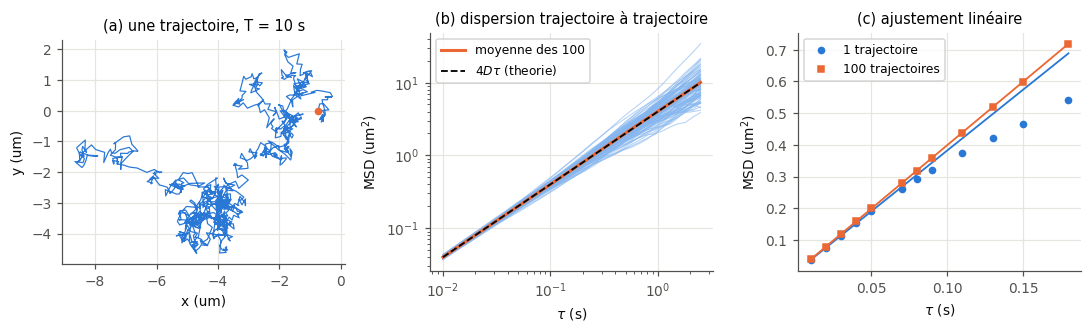

D vrai              : 1.000 um2/s
D, 1 trajectoire    : 0.956 um2/s
D, 100 trajectoires  : 0.998 um2/s


In [ ]:
# --- paramètres du simulateur 1 -------------------------------
D1 = 1.0          # coefficient de diffusion, um^2/s
DT1 = 0.01        # intervalle entre détections, s (100 images/s)
T1 = 10.0         # durée totale, s
SIG1 = 0.03       # précision de localisation, um
R_DISQUE = 1.0    # rayon du disque de confinement, um (cercle de 2 um de diamètre)
D_TUBE = 1.0      # diamètre du tube de confinement, um
N = 100           # nombre de trajectoires à simuler

t, R = simuler(Plan(2.), D1, T1, DT1, n=N, seed=11)    # 20 trajectoires indépendantes
tau_1, m_1 = msd(R[:, :1], DT1)                        # MSD d'une seule trajectoire
tau_e, m_e = msd(R, DT1)                               # MSD moyennée sur les 20
D_1, _ = ajuste_msd(tau_1, m_1)
D_e, _ = ajuste_msd(tau_e, m_e)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
ax[0].plot(*R[:, 0].T, color=CAT[0], lw=.8)
ax[0].plot(*R[0, 0], "o", color=CAT[1], label="depart")
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title("(a) une trajectoire, T = %g s" % T1)

for k in range(N):
    tk, mk = msd(R[:, k:k+1], DT1)
    ax[1].plot(tk, mk, color=SEQ[0], lw=.7, alpha=.6)

ax[1].plot(tau_e, m_e, color=CAT[1], label=f"moyenne des {N}")
ax[1].plot(tau_e, 4*D1*tau_e, "--", color="k", lw=1.2, label="$4D\\tau$ (theorie)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) dispersion trajectoire à trajectoire")

ax[2].plot(tau_1[:12], m_1[:12], "o", color=CAT[0], label="1 trajectoire")
ax[2].plot(tau_1[:12], 4*D_1*tau_1[:12], color=CAT[0], lw=1.2)
ax[2].plot(tau_e[:12], m_e[:12], "s", color=CAT[1], label=f"{N} trajectoires")
ax[2].plot(tau_e[:12], 4*D_e*tau_e[:12], color=CAT[1], lw=1.2)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("MSD (um$^2$)")
ax[2].legend()
ax[2].set_title("(c) ajustement linéaire")

plt.show()

print("D vrai               : %.3f um2/s" % D1)
print("D, 1 trajectoire     : %.3f um2/s" % D_1)
print(f"D, {N} trajectoires  : %.3f um2/s" % D_e)


**Conclusion.** La pente de la MSD aux courts décalages restitue $D$ correctement. Une trajectoire
unique suffit pour un estimateur non biaisé, mais sa MSD diverge fortement aux grands $\tau$ :
le nombre de paires indépendantes y devient très petit. On n'ajuste donc que les premiers points.

## B) Impact de la durée de la simulation

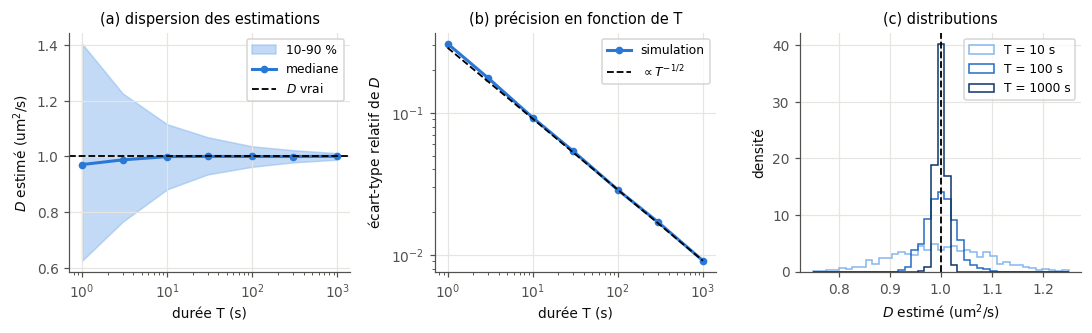

T =    1.0 s : D = 1.000 +- 0.308 um2/s  (31 %)
T =    3.0 s : D = 0.996 +- 0.175 um2/s  (18 %)
T =   10.0 s : D = 1.000 +- 0.093 um2/s  (9 %)
T =   30.0 s : D = 1.001 +- 0.054 um2/s  (5 %)
T =  100.0 s : D = 1.001 +- 0.029 um2/s  (3 %)
T =  300.0 s : D = 1.000 +- 0.017 um2/s  (2 %)
T = 1000.0 s : D = 1.000 +- 0.009 um2/s  (1 %)


In [ ]:
def D_par_trajectoire(R, dt, nlag=10):
    """
    D estimé individuellement pour chaque trajectoire (nlag premiers décalages).
    """

    lags = np.arange(1, nlag + 1)
    m = np.array([((R[l:] - R[:-l])**2).sum(-1).mean(0) for l in lags])
    
    return np.polyfit(lags*dt, m, 1)[0]/4

t, R = simuler(Plan(2.), D1, 1000., DT1, n=1000, seed=12)
durees = np.array([1, 3, 10, 30, 100, 300, 1000])
est = [D_par_trajectoire(R[:int(T/DT1) + 1], DT1) for T in durees]
med = np.array([np.median(e) for e in est])
p10 = np.array([np.percentile(e, 10) for e in est])
p90 = np.array([np.percentile(e, 90) for e in est])
cv = np.array([e.std()/e.mean() for e in est])

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

ax[0].fill_between(durees, p10, p90, color=SEQ[0], alpha=.5, label="10-90 %")
ax[0].plot(durees, med, "o-", color=CAT[0], label="mediane")
ax[0].axhline(D1, ls="--", color="k", lw=1.2, label="$D$ vrai")
ax[0].set_xscale("log")
ax[0].set_xlabel("durée T (s)")
ax[0].set_ylabel("$D$ estimé (um$^2$/s)")
ax[0].legend()
ax[0].set_title("(a) dispersion des estimations")

ax[1].plot(durees, cv, "o-", color=CAT[0], label="simulation")
ax[1].plot(durees, cv[-1]*np.sqrt(durees[-1]/durees), "--", color="k", lw=1.2, label="$\\propto T^{-1/2}$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("durée T (s)")
ax[1].set_ylabel("écart-type relatif de $D$")
ax[1].legend()
ax[1].set_title("(b) précision en fonction de T")

for c, T in zip(seq(4), [1, 10, 100, 1000]):
    ax[2].hist(est[list(durees).index(T)], bins=np.linspace(0.5, 1.5, 40), histtype="step", color=c, lw=1.8, label="T = %g s" % T, density=True)

ax[2].axvline(D1, ls="--", color="k", lw=1.2)
ax[2].set_xlabel("$D$ estimé (um$^2$/s)")
ax[2].set_ylabel("densité")
ax[2].legend()
ax[2].set_title("(c) distributions")

plt.show()

for T, e in zip(durees, est):
    print("T = %6.1f s : D = %.3f +- %.3f um2/s  (%.0f %%)" % (T, e.mean(), e.std(), 100*e.std()/e.mean()))


**Conclusion.** La durée ne change pas la valeur moyenne de $D$ : l'estimateur reste non biaisé.
Elle contrôle uniquement sa **précision**, qui s'améliore en $T^{-1/2}$. Sous 2 s (200 images),
la dispersion dépasse 25 % et une trajectoire isolée peut donner un $D$ deux fois trop grand ou
trop petit. C'est la raison pour laquelle on moyenne sur plusieurs trajectoires.

## C) Impact de la précision de localisation

Le bruit de localisation est décorrélé d'une image à l'autre : il ajoute une constante $4\sigma^2$
à la MSD 2D, sans modifier la pente (M14-15). On vérifie en même temps la règle du nombre
optimal de points $p_{\min} = E(2 + 2{,}7\sqrt{x})$ en comparant, sur des trajectoires **uniques**,
un ajustement à deux points à un ajustement à $p_{\min}$ points.

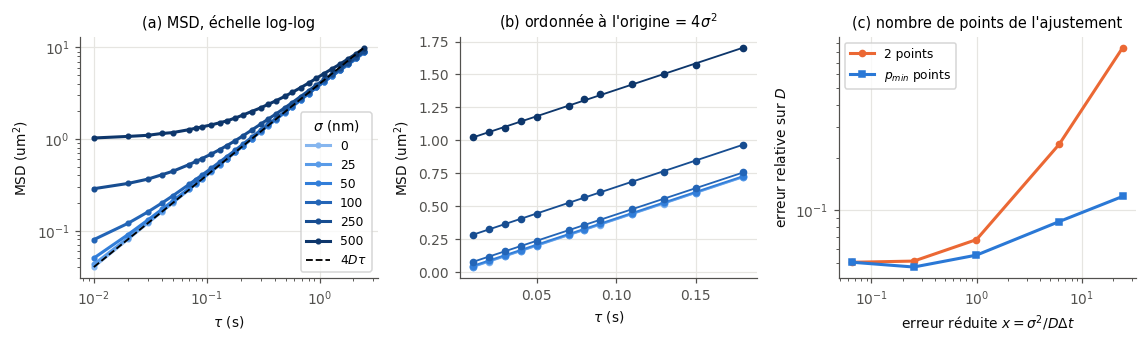

 sigma vrai   D estimé    sigma estimé      x     p_min   err(2 pts)  err(p_min)
      0 nm   1.001 um2/s       6 nm      0.004     2          5 %         5 %
     25 nm   1.001 um2/s      26 nm      0.066     2          5 %         5 %
     50 nm   1.000 um2/s      50 nm      0.253     3          5 %         5 %
    100 nm   0.997 um2/s     100 nm      0.997     4          7 %         6 %
    250 nm   1.005 um2/s     248 nm      6.103     8         24 %         9 %
    500 nm   1.001 um2/s     496 nm     24.542    15         85 %        12 %


In [24]:
sigmas = [0., 0.025, 0.05, 0.1, 0.25, 0.5]
t, R = simuler(Plan(2.), D1, 10.0, DT1, n=20, seed=13)

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
res = []

for c, s in zip(seq(len(sigmas)), sigmas):
    if s:
        Rb_ = bruit_localisation(R, s)
    else:
        Rb_ = R

    tau, m = msd(Rb_, DT1)
    Df, sf = ajuste_msd(tau, m)
    x = sf**2/(Df*DT1)
    p = min(int(2 + 2.7*np.sqrt(x)), len(tau))

    tau_p, mp = msd(Rb_, DT1, par_particule=True)
    D2 = np.array([ajuste_msd(tau_p, mp[:, k], npts=2)[0] for k in range(R.shape[1])])
    Dp = np.array([ajuste_msd(tau_p, mp[:, k], npts=p)[0] for k in range(R.shape[1])])
    res.append((s, Df, sf, x, p, D2.std()/abs(D2.mean()), Dp.std()/abs(Dp.mean())))

    ax[0].plot(tau, m, "o-", color=c, ms=3, label="%.0f" % (1000*s))
    ax[1].plot(tau[:12], m[:12], "o", color=c, ms=4)
    ax[1].plot(tau[:12], 4*Df*tau[:12] + 4*sf**2, color=c, lw=1.2)

ax[0].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("MSD (um$^2$)")
ax[0].legend(title="$\\sigma$ (nm)")
ax[0].set_title("(a) MSD, échelle log-log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].set_title("(b) ordonnée à l'origine = $4\\sigma^2$")

xs = [r[3] for r in res[1:]]

ax[2].plot(xs, [r[5] for r in res[1:]], "o-", color=CAT[1], label="2 points")
ax[2].plot(xs, [r[6] for r in res[1:]], "s-", color=CAT[0], label="$p_{min}$ points")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("erreur réduite $x = \\sigma^2/D\\Delta t$")
ax[2].set_ylabel("erreur relative sur $D$")
ax[2].legend()
ax[2].set_title("(c) nombre de points de l'ajustement")

plt.show()

print(" sigma vrai   D estimé    sigma estimé      x     p_min   err(2 pts)  err(p_min)")

for s, Df, sf, x, p, e2, ep in res:
    print("  %5.0f nm   %.3f um2/s   %5.0f nm   %8.3f   %3d    %7.0f %%   %7.0f %%" % (1000*s, Df, 1000*sf, x, p, 100*e2, 100*ep))


**Conclusion.** La précision de localisation décale la MSD vers le haut d'une constante $4\sigma^2$
sans changer la pente. Conséquences :

- $D$ reste correctement estimé **si** on ajuste une droite avec ordonnée à l'origine libre ;
  forcer le passage par zéro surestime $D$. Michalet insiste sur le point inverse : avec le temps de
  pose, l'ordonnée peut être **négative** ($a = 4\sigma^2 - \frac43 D t_E$) et la contraindre à
  rester positive biaise $D$ vers le bas.
- L'ordonnée à l'origine mesure $\sigma$ et le résultat est fidèle, à quelques nanomètres près.
- Le régime de courts $\tau$ devient plat : dès que $4\sigma^2 > 4D\Delta t$, c'est-à-dire dès que
  l'erreur réduite $x_\sigma = \sigma^2/(D\Delta t)$ dépasse 1 ($\sigma > \sqrt{D\Delta t} \approx 70$ nm
  ici), le mouvement réel est noyé dans le bruit sur les premiers points.
- **Le nombre de points ajustés compte autant que le modèle.** Tant que $x \lesssim 1$, deux ou
  trois points suffisent et les deux stratégies se valent. Dès que $x$ dépasse quelques unités,
  l'ajustement à deux points se disperse rapidement (44 % d'erreur relative à $x_\sigma = 31$) alors que
  $p_{\min} = E(2+2{,}7\sqrt{x})$ la maintient à 8 %. C'est le résultat central de Michalet : un
  nombre de points mal choisi peut fausser $D$ de plusieurs ordres de grandeur.

## D) Confinement

Cercle de 2 µm de diamètre ($R$ = 1 µm) et tube de 1 µm de diamètre.
Une particule confinée sature : $\mathrm{MSD}(\infty) = 2(\mathrm{Var}\,x + \mathrm{Var}\,y)$.

- disque uniforme : $\mathrm{Var}\,x = \mathrm{Var}\,y = R^2/4 \Rightarrow$ plateau $= R^2$
- segment de largeur $d$ : $\mathrm{Var} = d^2/12 \Rightarrow$ plateau 1D $= d^2/6$

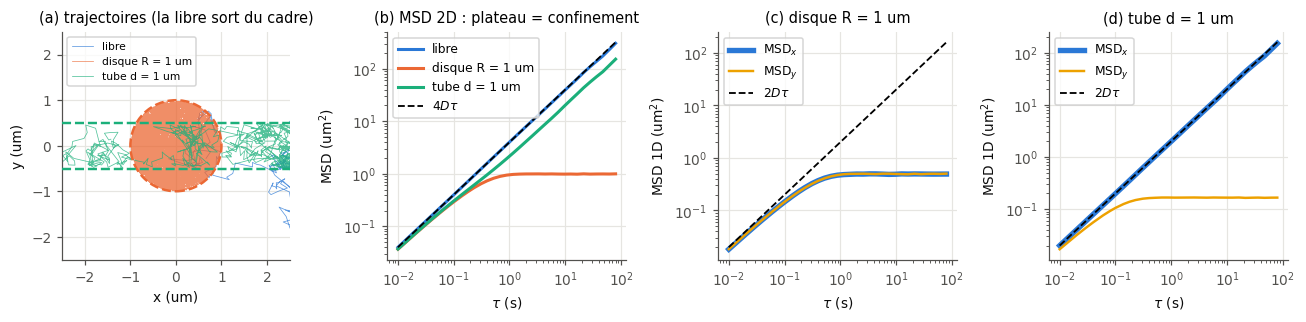

disque : plateau 2D = 0.993 um2  ->  R = 1.00 um (vrai 1.00)
tube   : plateau y  = 0.166 um2  ->  d = 1.00 um (vrai 1.00)
tube   : MSD_x linéaire, D_x = 0.995 um2/s (vrai 1.00)


In [12]:
T_LONG = 200.

geoms = [("libre", Plan(2.), CAT[0]),
         ("disque R = 1 um", Disque(R_DISQUE), CAT[1]),
         ("tube d = 1 um", Tube(D_TUBE), CAT[2])]

fig, ax = plt.subplots(1, 4, figsize=(12, 3.0))
traj = {}

for k, (nom, dom, c) in enumerate(geoms):
    t, R = simuler(dom, D1, T_LONG, DT1, n=30, seed=14)
    traj[nom] = R
    ax[0].plot(*R[:5000, 0].T, color=c, lw=.5, alpha=.75, label=nom)   # 50 s, cadre +-2.5 um
    tau, m = msd(R, DT1, frac=0.4)
    ax[1].plot(tau, m, color=c, lw=2, label=nom)

ax[0].add_patch(Circle((0, 0), R_DISQUE, fill=False, ec=CAT[1], lw=1.6, ls="--", zorder=5))

for y in (-D_TUBE/2, D_TUBE/2):
    ax[0].axhline(y, color=CAT[2], lw=1.6, ls="--", zorder=5)

ax[0].set_xlim(-2.5, 2.5)
ax[0].set_ylim(-2.5, 2.5)
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].legend(loc="upper left", fontsize=7)
ax[0].set_title("(a) trajectoires (la libre sort du cadre)")

ax[1].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) MSD 2D : plateau = confinement")

# decouplage des deux axes
for k, (nom, ax_k) in enumerate([("disque R = 1 um", ax[2]), ("tube d = 1 um", ax[3])]):
    for axe, lab, c, w in [(0, "x", CAT[0], 3.5), (1, "y", CAT[3], 1.6)]:
        tau, m = msd(traj[nom], DT1, frac=0.4, axe=axe)
        ax_k.plot(tau, m, color=c, lw=w, label="MSD$_%s$" % lab)

    ax_k.plot(tau, 2*D1*tau, "--", color="k", lw=1.2, label="$2D\\tau$")
    ax_k.set_xscale("log")
    ax_k.set_yscale("log")
    ax_k.set_xlabel("$\\tau$ (s)")
    ax_k.set_ylabel("MSD 1D (um$^2$)")
    ax_k.legend()
    ax_k.set_title("(%s) %s" % ("cd"[k], nom))

plt.show()

tau, m = msd(traj["disque R = 1 um"], DT1, frac=0.4)
print("disque : plateau 2D = %.3f um2  ->  R = %.2f um (vrai %.2f)" % (plateau(tau, m), np.sqrt(plateau(tau, m)), R_DISQUE))

tau, my = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=1)
print("tube   : plateau y  = %.3f um2  ->  d = %.2f um (vrai %.2f)" % (plateau(tau, my), np.sqrt(6*plateau(tau, my)), D_TUBE))

tau, mx = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=0)
print("tube   : MSD_x linéaire, D_x = %.3f um2/s (vrai %.2f)" % (ajuste_msd(tau, mx, ndim=1)[0], D1))

**Conclusion.**

- Le confinement fait **saturer** la MSD : elle suit $4D\tau$ aux courts $\tau$, puis s'infléchit
  et atteint un plateau au temps caractéristique $\tau_c \approx R^2/D$.
- Le plateau donne directement la taille du domaine : $R = \sqrt{\mathrm{MSD}_\infty}$ pour le
  disque, $d = \sqrt{6\,\mathrm{MSD}_{y,\infty}}$ pour le tube. Les deux tailles sont retrouvées
  à quelques pour cent.
- **Le découplage des axes est indispensable pour le tube.** En 2D, la MSD totale du tube reste
  croissante (le mouvement libre selon $x$ masque le confinement) et on pourrait conclure à tort à
  une diffusion libre plus lente. Projetée sur chaque axe, la signature est sans ambiguïté :
  MSD$_x$ reste linéaire de pente $2D$, MSD$_y$ plafonne. Pour le disque, les deux axes plafonnent
  à la même valeur $R^2/2$, ce qui signe un confinement isotrope.

## E) Film vu par une caméra

La trajectoire est convoluée par une PSF gaussienne, échantillonnée par les pixels, puis un fond et
un bruit de Poisson sont ajoutés.

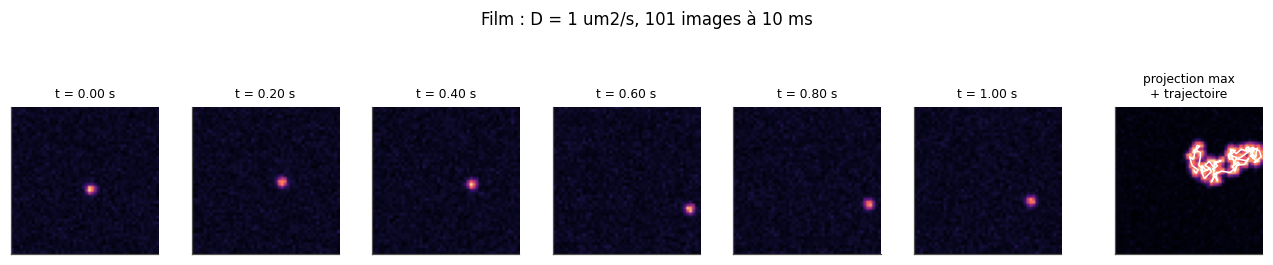

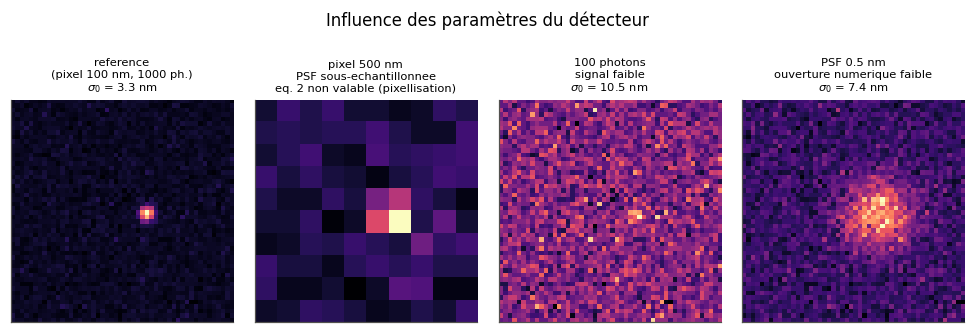

PSF                 : sigma = 105 nm  (FWHM = 247 nm), lambda = 0.5 um, NA = 1.0
Pixel               : 100 nm  -> 1.0 pixels par sigma de PSF (critère de Nyquist)
Photons / molécule  : 1000 par image ; fond : 10 photons/pixel
Localisation        : sigma_0 = s0/sqrt(N) = 3.3 nm  (statique, Michalet eq. 2)
                      sigma   = 4.6 nm  (pose t_E = 10 ms, eq. 4)
Déplacement / image : sqrt(4 D dt) = 200 nm
Erreur réduite      : x = sigma^2/(D dt) = 1.1e-03  ->  p_min = 2 points de MSD


In [13]:
# --- paramètres du détecteur ------------------------------------------------
LAMBDA = 0.500          # longueur d'onde d'emission, um
NA = 1.0                # ouverture numérique
PSF = 0.21*LAMBDA/NA    # écart-type de la PSF ~ 0.21 lambda/NA
CHAMP = 5               # largeur du champ, um
PIXEL = 0.1             # largeur d'un pixel, um
PHOTONS = 1000          # nombre de photons détectés

cam = Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS, fond=10)

t, R = simuler(Plan(1.), D1, 1.0, DT1, n=1, seed=15)
film = cam.film(R, seed=15)

fig, ax = plt.subplots(1, 7, figsize=(12, 2.1), width_ratios=[1]*6 + [1.25])

for a_, i in zip(ax, np.linspace(0, len(film) - 1, 6).astype(int)):
    a_.imshow(film[i], vmin=0, vmax=film.max())
    a_.set_title("t = %.2f s" % t[i], fontsize=8)

ax[6].imshow(film.max(0), extent=[-cam.champ/2, cam.champ/2]*2, origin="lower")
ax[6].plot(*R[:, 0].T, color="w", lw=1)
ax[6].set_title("projection max\n+ trajectoire", fontsize=8)

for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Film : D = %g um2/s, %d images à %g ms" % (D1, len(film), 1e3*DT1), y=1.12)

plt.show()

# influence de chaque paramètre du détecteur, sur la même position
variantes = [(f"reference\n(pixel {PIXEL*1000:.0f} nm, {PHOTONS} ph.)", cam, True),
             (f"pixel {PIXEL*5*1000:.0f} nm\nPSF sous-echantillonnee",
              Camera(pixel=PIXEL*5, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), False),
             (f"{PHOTONS//10} photons\nsignal faible",
              Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), True),
             (f"PSF {PSF*5:.1f} nm\nouverture numerique faible",
              Camera(pixel=PIXEL, psf=PSF*5, champ=CHAMP, photons=PHOTONS*5, fond=10), True)]

fig, ax = plt.subplots(1, 4, figsize=(9, 2.7))

for a_, (titre, c, valide) in zip(ax, variantes):
    a_.imshow(c.image(R[20], np.random.default_rng(1)))

    if valide:
        sous_titre = "$\\sigma_0$ = %.1f nm" % (1000*c.precision())
    else:
        sous_titre = "eq. 2 non valable (pixellisation)"

    a_.set_title("%s\n%s" % (titre, sous_titre), fontsize=7.5)
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Influence des paramètres du détecteur", y=1.10)

plt.show()

print("PSF                 : sigma = %.0f nm  (FWHM = %.0f nm), lambda = %g um, NA = %.1f" % (1000*PSF, 1000*2.355*PSF, LAMBDA, NA))
print("Pixel               : %.0f nm  -> %.1f pixels par sigma de PSF (critère de Nyquist)" % (1000*cam.pixel, PSF/cam.pixel))
print("Photons / molécule  : %d par image ; fond : %d photons/pixel" % (cam.photons, cam.fond))
print("Localisation        : sigma_0 = s0/sqrt(N) = %.1f nm  (statique, Michalet eq. 2)" % (1000*cam.precision()))
print("                      sigma   = %.1f nm  (pose t_E = %g ms, eq. 4)" % (1000*cam.precision_dynamique(D1, DT1), 1e3*DT1))
print("Déplacement / image : sqrt(4 D dt) = %.0f nm" % (1000*np.sqrt(4*D1*DT1)))
print("Erreur réduite      : x = sigma^2/(D dt) = %.1e  ->  p_min = %d points de MSD" % (cam.precision()**2/(D1*DT1), int(2 + 2.7*np.sqrt(cam.precision()**2/(D1*DT1)))))

**Conclusion — choix des paramètres.**

- **PSF** : $s_0 \simeq 0{,}21\,\lambda/\mathrm{NA} = 78$ nm (FWHM 184 nm) pour
  $\lambda$ = 520 nm et NA = 1,4. C'est la limite de diffraction ; élargir la PSF dégrade
  directement la précision de localisation.
- **Pixel** : 100 nm, soit 0,8 pixel par $s_0$ (il faut au moins deux pixels par FWHM, soit
  92 nm). Trop gros (300 nm), la PSF n'est plus échantillonnée : l'information de position est
  perdue et $\sigma_0 = s_0/\sqrt{N_{ph}}$ (M2), qui néglige justement la pixellisation, cesse de s'appliquer.
  Trop petit, les photons sont répartis sur trop de pixels et le bruit de lecture domine.
- **Photons** : 600 par molécule et par image, soit $\sigma_0 = s_0/\sqrt{N_{ph}}$ = 3,2 nm, très
  inférieur au déplacement par image ($\sqrt{4D\Delta t}$ = 141 nm) : la trajectoire est largement
  sur-résolue. À 60 photons la précision tombe à 10 nm, et une PSF dégradée à 350 nm la porte à
  14 nm. La correction de pose (M4) ajoute encore 35 % ici, car $D t_E \simeq s_0^2$.
- **Lien avec la partie C** : avec ces photons, $x_\sigma = \sigma^2/(D\Delta t) \approx 2\times10^{-3}$,
  donc $p_{\min} = 2$ : deux points de MSD suffisent. C'est le régime $x \ll 1$ de Michalet.
- **Fond et bruit de Poisson** : le fond (10 photons/pixel) ajoute du bruit sans signal et pénalise
  surtout les images faibles ; le bruit de grenaille est la limite fondamentale.
- **$\Delta t$** : 10 ms fixe à la fois la fréquence d'images et le déplacement par image. Il doit
  rester petit devant le temps de confinement mais assez grand pour collecter des photons.

<a id="2"></a>
# 2. Simulateur 2 — FRAP

Population de particules indépendantes dans une boîte à parois réfléchissantes. Paramètres :
durée $T$, pas $\Delta t$, densité de particules, coefficient de diffusion $D$, fraction immobile,
rayon de la zone blanchie $R_b$.

Référence : **Kenworthy, *Biophys. J.* 122, 3577 (2023)**. L'article rappelle qu'une courbe de FRAP
porte deux informations distinctes, la **cinétique** (caractérisée par $t_{1/2}$) et la **fraction
mobile**, et que le choix du modèle doit tenir compte de la géométrie et de la taille de la zone
blanchie, des conditions aux limites et du nombre de dimensions du retour. C'est le plan des trois
parties ci-dessous.

L'analyse se limite donc à ces deux grandeurs, extraites par un ajustement mono-exponentiel :
$D$ est ici un **paramètre d'entrée** de la simulation, jamais une quantité mesurée sur la courbe. Les trois hypothèses de base qu'il liste (blanchiment irréversible, variations
de fluorescence dues aux seules molécules marquées, marquage non perturbant) sont ici satisfaites
par construction.

## Film FRAP vu par la caméra

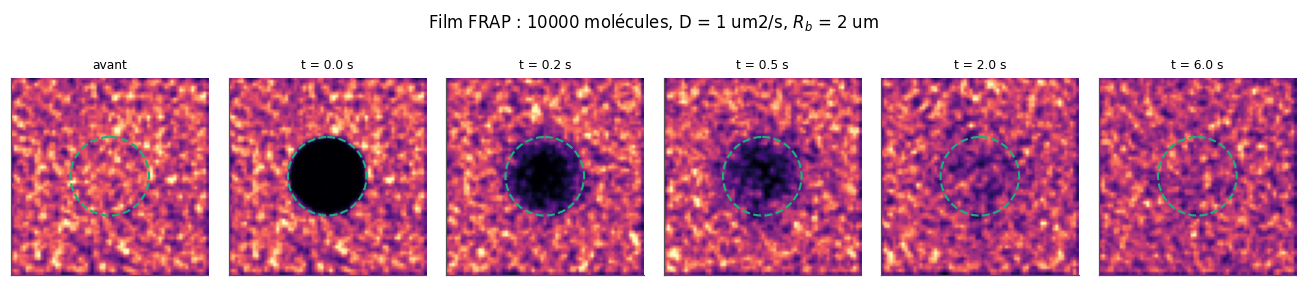

In [25]:
# --- paramètres de référence du simulateur 2 -------------------------------
L2 = 10.0                   # côté de la boîte, um (grande devant Rb pour un réservoir quasi infini)
RB = 2.0                    # rayon de la zone blanchie, um
DENS2 = 100.0                # densité, molécules / um^2
N2 = int(DENS2*L2**2)       # nombre de molécules
D2 = 1.0                    # coefficient de diffusion, um^2/s

t, R = simuler(Boite(L2), D2, 6.0, 0.05, n=N2, seed=20)
fluo = (R[0]**2).sum(-1) >= RB**2                 # molécules non blanchies
cam = Camera(pixel=0.15, psf=PSF, champ=10., photons=200, fond=5)

instants = [0, 0, 4, 10, 40, 120]
fig, ax = plt.subplots(1, 6, figsize=(12, 2.4))
rng = np.random.default_rng(3)
ech = cam.image(R[0], rng)                          # image avant blanchiment
vmax = np.percentile(ech, 99.5)

for k, (a, i) in enumerate(zip(ax, instants)):
    if k == 0:
        m = np.ones(N2, bool)          # 1re vignette : avant blanchiment
        titre = "avant"
    else:
        m = fluo
        titre = "t = %.1f s" % t[i]

    a.imshow(cam.image(R[i][m], rng), vmin=0, vmax=vmax)
    a.add_patch(Circle((cam.npix/2 - .5,)*2, RB/cam.pixel, fill=False, ec=CAT[2], lw=1.4, ls="--"))
    a.set_title(titre, fontsize=8)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

fig.suptitle("Film FRAP : %d molécules, D = %g um2/s, $R_b$ = %g um" % (N2, D2, RB), y=1.06)

plt.show()


## A) Impact du coefficient de diffusion

$\Delta t$ et $T$ sont mis à l'échelle du temps caractéristique $R_b^2/D$, ce qui garde le même
nombre de points utiles quel que soit $D$.

La boîte fait 10 µm de côté pour un disque de rayon 2 µm, soit un rapport d'aire de 12,6 %. Le
plateau ne peut donc pas atteindre 1 : les molécules blanchies se diluent dans la boîte au lieu
d'en sortir, et le retour plafonne à $F_\infty = 1 - \pi R_b^2/L^2 = 0{,}874$. C'est cette valeur
qui sert de référence.

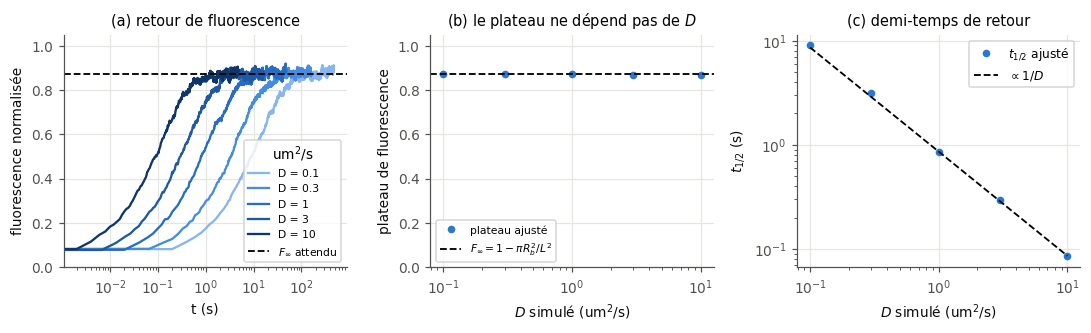

  plateau attendu en boîte fermée : F_inf = 1 - pi Rb^2/L^2 = 0.874

  D simulé    plateau    t_1/2 (s)    t_1/2 x D
     0.10      0.872       8.981        0.898
     0.30      0.871       3.146        0.944
     1.00      0.871       0.860        0.860
     3.00      0.868       0.292        0.877
    10.00      0.867       0.085        0.848


In [26]:
Ds = [0.1, 0.3, 1.0, 3.0, 10.0]
courbes = []
ajust = []

for k, D in enumerate(Ds):
    t, F = frap(Boite(L2), D, RB, 12*RB**2/D, 0.005*RB**2/D, N2, n_rep=4, seed=21 + 100*k)
    courbes.append((t, F))
    ajust.append(ajuste_frap(t, F))

F_INF = plateau_attendu(RB, L2)
fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, D, (t, F) in zip(seq(len(Ds)), Ds, courbes):
    ax[0].plot(t, F, color=c, lw=1.5, label="D = %g" % D)

ax[0].axhline(F_INF, ls="--", color="k", lw=1.2, label="$F_\\infty$ attendu")
ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="um$^2$/s", fontsize=7)
ax[0].set_title("(a) retour de fluorescence")

ax[1].plot(Ds, [a["mobile"] for a in ajust], "o", color=CAT[0], label="plateau ajusté")
ax[1].axhline(F_INF, ls="--", color="k", lw=1.2, label="$F_\\infty = 1 - \\pi R_b^2/L^2$")
ax[1].set_xscale("log")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("$D$ simulé (um$^2$/s)")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) le plateau ne dépend pas de $D$")

t_demis = np.array([a["t_demi"] for a in ajust])
ref = t_demis[Ds.index(1.0)]/np.array(Ds)

ax[2].plot(Ds, t_demis, "o", color=CAT[0], label="$t_{1/2}$ ajusté")
ax[2].plot(Ds, ref, "--", color="k", lw=1.2, label="$\\propto 1/D$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$D$ simulé (um$^2$/s)")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend()
ax[2].set_title("(c) demi-temps de retour")

plt.show()

print("  plateau attendu en boîte fermée : F_inf = 1 - pi Rb^2/L^2 = %.3f" % F_INF)
print()
print("  D simulé    plateau    t_1/2 (s)    t_1/2 x D")

for D, a in zip(Ds, ajust):
    print("  %7.2f    %7.3f    %8.3f    %9.3f" % (D, a["mobile"], a["t_demi"], a["t_demi"]*D))

**Conclusion.** Les deux grandeurs lues sur la courbe se comportent de façon indépendante.

- **La cinétique suit $D$.** Le produit $t_{1/2} \times D$ reste constant à 0,87 ± 0,02 s·µm²/s sur
  deux décades (panneau c), donc $t_{1/2} \propto 1/D$ : un facteur 100 sur $D$ donne un facteur 100
  sur le demi-temps. C'est une mise à l'échelle mesurée, pas un modèle ajusté.
- **Le plateau ignore $D$.** Il vaut 0,87 dans les cinq cas (panneau b), en accord avec
  $F_\infty = 1 - \pi R_b^2/L^2 = 0{,}874$. La mobilité change la vitesse du retour, jamais son
  amplitude finale.

L'ajustement mono-exponentiel donne donc bien $t_{1/2}$ et la fraction mobile, mais il ne fournit
aucun $D$ : la constante 0,87 s·µm²/s qui relie $t_{1/2}$ à $1/D$ dépend du modèle de diffusion et
de la géométrie, et l'exponentielle ne les contient pas. Pour un $D$ quantitatif il faudrait la
solution du problème de diffusion dans la géométrie considérée, ce que Kenworthy signale
explicitement.

## B) Impact de la population immobile

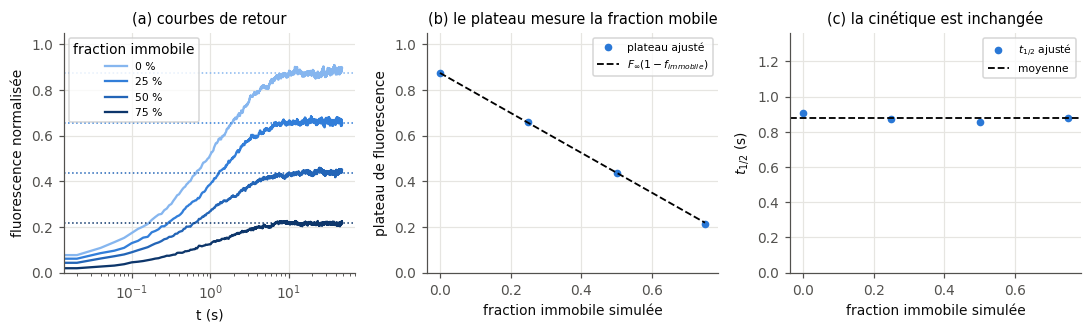

  f_immobile   plateau mesuré   plateau attendu   t_1/2 (s)
      0.00            0.874             0.874       0.908
      0.25            0.658             0.656       0.873
      0.50            0.436             0.437       0.856
      0.75            0.214             0.219       0.877


In [27]:
f_imm = [0., 0.25, 0.5, 0.75]
res_b = []

for k, fi in enumerate(f_imm):
    t, F = frap(Boite(L2), D2, RB, 12*RB**2/D2, 0.005*RB**2/D2, N2, f_immobile=fi, n_rep=6, seed=22 + 100*k)
    res_b.append((t, F, ajuste_frap(t, F)))

attendus = [plateau_attendu(RB, L2, fi) for fi in f_imm]
fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, fi, att, (t, F, a) in zip(seq(len(f_imm)), f_imm, attendus, res_b):
    ax[0].plot(t, F, color=c, lw=1.5, label="%.0f %%" % (100*fi))
    ax[0].axhline(att, color=c, ls=":", lw=1)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="fraction immobile", fontsize=7)
ax[0].set_title("(a) courbes de retour")

ax[1].plot(f_imm, [a["mobile"] for _, _, a in res_b], "o", color=CAT[0], label="plateau ajusté")
ax[1].plot(f_imm, attendus, "--", color="k", lw=1.2, label="$F_\\infty(1 - f_{immobile})$")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("fraction immobile simulée")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) le plateau mesure la fraction mobile")

ax[2].plot(f_imm, [a["t_demi"] for _, _, a in res_b], "o", color=CAT[0], label="$t_{1/2}$ ajusté")
ax[2].axhline(np.mean([a["t_demi"] for _, _, a in res_b]), ls="--", color="k", lw=1.2, label="moyenne")
ax[2].set_ylim(0, 1.5*max(a["t_demi"] for _, _, a in res_b))
ax[2].set_xlabel("fraction immobile simulée")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) la cinétique est inchangée")

plt.show()

print("  f_immobile   plateau mesuré   plateau attendu   t_1/2 (s)")

for fi, att, (_, _, a) in zip(f_imm, attendus, res_b):
    print("  %8.2f     %12.3f     %13.3f    %8.3f" % (fi, a["mobile"], att, a["t_demi"]))

**Conclusion.** La population immobile ne change pas la **vitesse** du retour, seulement son
**amplitude finale**.

- **Le plateau mesure la fraction mobile** (panneau b) : 0,870, 0,659, 0,437 et 0,213 pour des
  fractions immobiles de 0, 25, 50 et 75 %, contre 0,874, 0,656, 0,437 et 0,219 attendus. Les
  molécules fixes blanchies restent dans la zone et n'en sortent jamais, celles de l'extérieur n'y
  entrent jamais. La fluorescence manquante au plateau est donc la mesure directe de la fraction
  immobile, à condition de rapporter la mesure à $F_\infty$ et non à 1.
- **La cinétique est inchangée** (panneau c) : $t_{1/2}$ reste autour de 0,83 s quelle que soit la
  fraction immobile, car il ne dépend que de la mobilité de la population qui bouge.

Les deux informations n'interfèrent donc pas : l'une est portée par l'amplitude, l'autre par
l'échelle de temps. La légère baisse de $t_{1/2}$ à 75 % d'immobiles vient de ce que l'amplitude
qui remonte devient faible, ce qui rend l'ajustement plus sensible au bruit.

## C) Impact de la géométrie : 2D libre contre tube de 1 µm

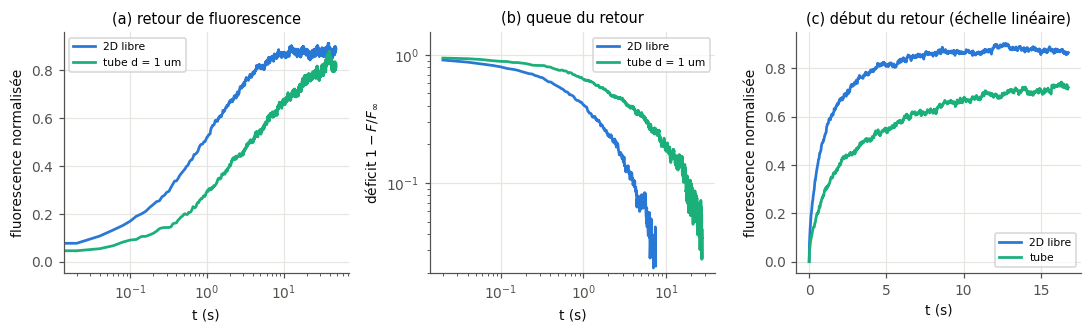

  géométrie        plateau   t_1/2 (s)   pente du déficit sur 1-5 s
  2D libre           0.873      0.903            -1.17
  tube d = 1 um      0.793      3.022            -0.42


In [36]:
L_TUBE = 100.0
DENS_TUBE = 100.0
PLANCHER = 0.02        # sous ce deficit, F fluctue autour du plateau : c'est du bruit
FEN_PENTE = (1.0, 5.0)  # fenetre de temps ou l'on compare les pentes, en s

geo = [("2D libre", Boite(L2), N2, CAT[0]),
       ("tube d = 1 um", Tube(1.0, L_TUBE), int(DENS_TUBE*L_TUBE), CAT[2])]
res_c = []

for k, (nom, dom, n, c) in enumerate(geo):
    t, F = frap(dom, D2, RB, 12*RB**2, 0.005*RB**2, n, n_rep=4, seed=23 + 100*k)
    res_c.append((nom, t, F, c))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
pentes = []

for nom, t, F, c in res_c:
    A = F[int(0.8*len(F)):].mean()
    deficit = 1 - F[1:]/A
    tt = t[1:]

    # on coupe au premier passage sous le plancher, sinon le deficit devient
    # negatif et l'echelle log part en vrille
    sous = np.flatnonzero(deficit < PLANCHER)

    if len(sous):
        fin = sous[0]
    else:
        fin = len(deficit)

    # pente sur une fenetre de temps COMMUNE aux deux geometries : comparer a
    # deficit egal comparerait des instants differents, et les deux courbes
    # s'accentuent avec le temps, ce qui inverserait la conclusion
    util = (tt >= FEN_PENTE[0]) & (tt <= FEN_PENTE[1]) & (deficit > PLANCHER)
    pentes.append(np.polyfit(np.log(tt[util]), np.log(deficit[util]), 1)[0])

    ax[0].plot(t, F, color=c, lw=1.8, label=nom)
    ax[1].plot(tt[:fin], deficit[:fin], color=c, lw=1.8, label=nom)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].legend(fontsize=7)
ax[0].set_title("(a) retour de fluorescence")

ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_ylim(PLANCHER, 1.5)
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("déficit $1 - F/F_\\infty$")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) queue du retour")

i = int(0.35*len(res_c[0][1]))

ax[2].plot(res_c[0][1][:i], res_c[0][2][:i], color=CAT[0], lw=1.8, label="2D libre")
ax[2].plot(res_c[0][1][:i], res_c[1][2][:i], color=CAT[2], lw=1.8, label="tube")
ax[2].set_xlabel("t (s)")
ax[2].set_ylabel("fluorescence normalisée")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) début du retour (échelle linéaire)")

plt.show()

print("  géométrie        plateau   t_1/2 (s)   pente du déficit sur %g-%g s" % FEN_PENTE)

for (nom, t, F, c), p in zip(res_c, pentes):
    a = ajuste_frap(t, F)
    print("  %-14s   %7.3f   %8.3f   %14.2f" % (nom, a["mobile"], a["t_demi"], p))

**Conclusion.** La géométrie change la **forme** de la courbe, pas seulement son échelle de temps.

- **Le retour est trois fois plus lent dans le tube** : $t_{1/2}$ = 3,0 s contre 0,9 s en 2D libre,
  pour un $D$ **identique**. En 2D, le disque se remplit par tout son périmètre ; dans le tube, les
  molécules n'arrivent que par les deux extrémités, et il n'y a aucune autre voie d'accès.
- **La queue du déficit décroît beaucoup plus lentement** (panneau b) : sur la fenêtre 1-5 s, la
  pente vaut $-1{,}17$ en 2D contre $-0{,}42$ dans le tube, soit près d'un facteur trois. Ces pentes
  doivent être comparées **au même instant**, car elles s'accentuent continûment au cours du retour :
  la boîte est finie, le réservoir de molécules fluorescentes s'appauvrit, et la décroissance
  s'accélère à mesure que le plateau approche. On ne peut donc pas attribuer un exposant unique à
  chaque géométrie, seulement constater que le tube traîne nettement plus longtemps.
- **Le plateau est aussi plus bas dans le tube**, 0,79 contre 0,87, pour la même raison
  géométrique : le réservoir accessible à une seule dimension est plus petit.

Conséquence pratique : ce facteur trois sur $t_{1/2}$ est un effet de **géométrie**, pas de
mobilité. Qui lirait ces deux courbes en supposant la même géométrie concluerait à une diffusion
trois fois plus lente dans le tube, alors que $D$ est le même. C'est exactement le point soulevé par
Kenworthy : le modèle doit tenir compte des conditions aux limites et du nombre de dimensions du
retour. Il faut donc vérifier la forme de la courbe, et pas seulement lire $t_{1/2}$, avant de
conclure à une mobilité réduite.

<a id="3"></a>
# 3. Simulateur 3 — FCS

Un laser gaussien est focalisé au centre de la boîte. On enregistre la trace de fluorescence
$F(t)$ et on calcule $G(\tau) = \langle \delta F(t)\,\delta F(t+\tau)\rangle / \langle F\rangle^2$.

L'ajustement donne $N = 1/G(0)$ (nombre d'émetteurs dans la surface effective $\pi w_0^2$) et
$\tau_D = w_0^2/4D$ (temps de résidence).

Les paramètres reproduisent une mesure de FCS confocale sur une membrane : faisceau de rayon
$w_0$ = 0,25 µm à $1/e^2$ (objectif à immersion NA 1,2, émission ~520 nm), densités de 0,5 à
51 molécules/µm² et coefficients de diffusion de 0,1 à 10 µm²/s, qui couvrent la gamme des lipides
et des protéines membranaires. Le binning et la durée d'acquisition
sont calés sur le temps de résidence attendu, à raison de 100 points par $\tau_D$ et de
1000 $\tau_D$ par acquisition : c'est ce qui donne des courbes de même qualité sur toute la gamme.

Référence : **Yu *et al.*, *Front. Phys.* 9, 644450 (2021)**, dont on reprend la définition de
$G(\tau)$ (Y1), le modèle de diffusion réduit au cas 2D (Y2) et les ordres de grandeur du
tableau 1 pour la FCS conventionnelle : gamme de concentration de 1 pM à 100 nM, $D$ mesurable
jusqu'à 300 µm²/s, durée d'acquisition typique de 10 à 120 s.

## Mesure de référence : densité et temps de résidence

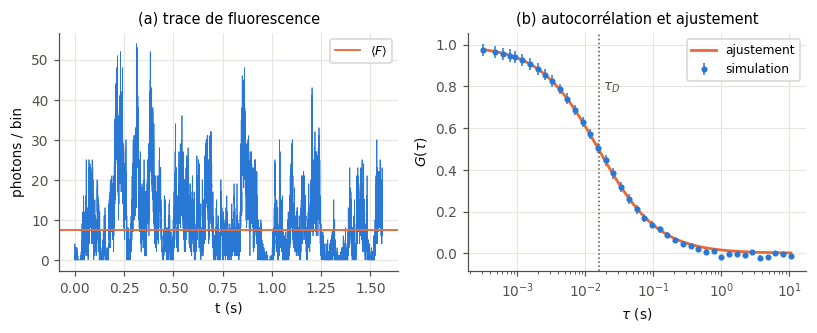

Faisceau     : w0 = 0.25 um -> surface effective pi*w0^2 = 0.196 um2
Boîte        : 4 x 4 um (16 w0), 81 molécules -> 5.1 molécules/um2
Acquisition  : dt = 156 us, T = 15.6 s = 1000 tau_D, 100000 points
Photons      : 100 kHz par molécule -> 7.6 photons/bin en moyenne

N     : 1.00 émetteurs   (simulé : 1.00)
tau_D : 15.7 ms          (attendu : 15.6 ms)
D     : 0.99 um2/s       (simulé : 1.00)


In [ ]:
# --- paramètres de référence du simulateur 3 -------------------------------
W0 = 0.25         # rayon du faisceau à 1/e^2, um (valeur calibrée typique)
L3 = 4.0          # côté de la boîte, um = 16 w0 : en dessous, les parois biaisent tau_D
D3 = 1.0          # coefficient de diffusion, um^2/s
N_EFF = 1.0       # émetteurs par surface effective pi*w0^2
CPS = 1e5         # brillance : 100 kHz par molécule au centre du faisceau

# le binning et la durée sont calés sur le temps de résidence attendu :
# 100 points par tau_D pour décrire la décroissance, 1000 tau_D pour la statistique
TAU_D3 = W0**2/(4*D3)
DT3 = TAU_D3/100
T3 = 1000*TAU_D3
n3 = n_particules(N_EFF, L3**2, W0)

tau, G, err, F = fcs(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), n_rep=8, seed=30, cps=CPS)
res = ajuste_fcs(tau, G, W0)
fen = slice(0, 10000)                     # ~100 temps de residence : fenetre representative

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))

ax[0].plot(np.arange(10000)*DT3, F[fen], color=CAT[0], lw=.5)
ax[0].axhline(F.mean(), color=CAT[1], lw=1.2, label="$\\langle F \\rangle$")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].legend()
ax[0].set_title("(a) trace de fluorescence")

ax[1].errorbar(tau, G, err, fmt="o", color=CAT[0], ms=3, lw=1, label="simulation")
ax[1].plot(tau, modele_fcs(tau, 1/res["N"], res["tau_D"]), color=CAT[1], lw=1.8, label="ajustement")
ax[1].axvline(res["tau_D"], color=GRIS, ls=":", lw=1)
ax[1].annotate("$\\tau_D$", (res["tau_D"]*1.15, G.max()*.8), color=GRIS)
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].legend()
ax[1].set_title("(b) autocorrélation et ajustement")

plt.show()

print("Faisceau     : w0 = %.2f um -> surface effective pi*w0^2 = %.3f um2" % (W0, np.pi*W0**2))
print("Boîte        : %.0f x %.0f um (%.0f w0), %d molécules -> %.1f molécules/um2" % (L3, L3, L3/W0, n3, n3/L3**2))
print("Acquisition  : dt = %.0f us, T = %.1f s = %.0f tau_D, %d points" % (1e6*DT3, T3, T3/TAU_D3, int(T3/DT3)))
print("Photons      : %.0f kHz par molécule -> %.1f photons/bin en moyenne" % (CPS/1e3, F.mean()))
print()
print("N     : %.2f émetteurs   (simulé : %.2f)" % (res["N"], N_EFF))
print("tau_D : %.1f ms          (attendu : %.1f ms)" % (1e3*res["tau_D"], 1e3*TAU_D3))
print("D     : %.2f um2/s       (simulé : %.2f)" % (res["D"], D3))

**Conclusion.** L'amplitude $G(0) = 1/N$ donne la densité et le temps de décroissance donne
$\tau_D$, donc $D = w_0^2/4\tau_D$. Les deux grandeurs sont retrouvées à quelques pour cent, et
elles sont indépendantes : l'une est portée par l'amplitude, l'autre par la position en temps.

## Impact du coefficient de diffusion (0,1 à 10 µm²/s)

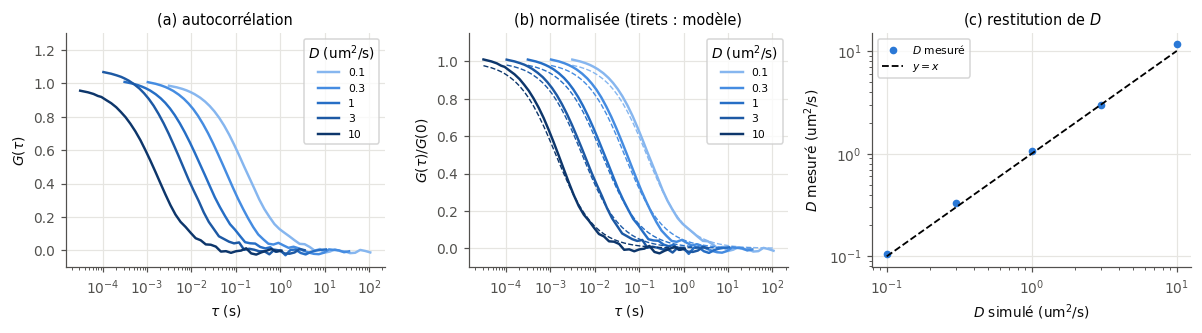

  D simulé   tau_D attendu   tau_D mesuré   D mesuré   N mesuré   dt (us)   T (s)
     0.10        156.25         148.49       0.11       0.99    1562.5   156.2
     0.30         52.08          46.86       0.33       0.96     520.8    52.1
     1.00         15.62          14.76       1.06       0.97     156.2    15.6
     3.00          5.21           5.23       2.99       0.91      52.1     5.2
    10.00          1.56           1.34      11.68       1.01      15.6     1.6


In [19]:
Ds3 = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
res_D = []

for k, (c, D) in enumerate(zip(seq(len(Ds3)), Ds3)):
    tauD = W0**2/(4*D)
    tau, G, err, _ = fcs(Boite(L3), D, 1000*tauD, tauD/100, n3, Faisceau(W0), n_rep=8, seed=31 + 100*k, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_D.append(r)

    ax[0].plot(tau, G, color=c, lw=1.6, label="%g" % D)
    ax[1].plot(tau, G/G[:3].mean(), color=c, lw=1.6, label="%g" % D)
    ax[1].plot(tau, modele_fcs(tau, 1., r["tau_D"]), color=c, lw=.9, ls="--")

ax[0].set_xscale("log")
ax[0].set_ylim(-0.1, 1.3)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="$D$ (um$^2$/s)", fontsize=7)
ax[0].set_title("(a) autocorrélation")

ax[1].set_xscale("log")
ax[1].set_ylim(-0.1, 1.15)
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)/G(0)$")
ax[1].legend(title="$D$ (um$^2$/s)", fontsize=7)
ax[1].set_title("(b) normalisée (tirets : modèle)")

ax[2].plot(Ds3, [r["D"] for r in res_D], "o", color=CAT[0], label="$D$ mesuré")
ax[2].plot(Ds3, Ds3, "--", color="k", lw=1.2, label="$y = x$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$D$ simulé (um$^2$/s)")
ax[2].set_ylabel("$D$ mesuré (um$^2$/s)")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) restitution de $D$")

plt.show()

print("  D simulé   tau_D attendu   tau_D mesuré   D mesuré   N mesuré   dt (us)   T (s)")

for D, r in zip(Ds3, res_D):
    tauD = W0**2/(4*D)
    print("  %7.2f   %11.2f   %12.2f   %8.2f   %8.2f   %7.1f   %5.1f" % (D, 1e3*tauD, 1e3*r["tau_D"], r["D"], r["N"], 1e6*tauD/100, 1000*tauD))

**Conclusion.** $D$ déplace la courbe **horizontalement sans changer son amplitude**, et les deux
premiers panneaux le montrent séparément. Au panneau (a), les cinq courbes brutes partent toutes du
même $G(0) \simeq 1$, puisque la densité est la même partout : seule la position de la décroissance
change. Au panneau (b), une fois normalisées, elles gardent la même forme en $1/(1+\tau/\tau_D)$,
que le modèle en tirets suit dans les cinq cas.

$\tau_D$ passe de 156 ms à 1,6 ms sur deux décades et $D$ est restitué le long de la droite $y = x$
(panneau c), à mieux que 7 % sur toute la gamme. La densité mesurée reste à 1 émetteur quel que soit
$D$, ce qui confirme que **mobilité et concentration sont découplées** : l'une se lit sur l'échelle
de temps, l'autre sur l'amplitude.

Les cinq courbes ont le même niveau de bruit parce que le pas d'échantillonnage et la durée suivent
$\tau_D$ : 1,6 ms et 156 s pour $D$ = 0,1 µm²/s, 16 µs et 1,6 s pour $D$ = 10 µm²/s. C'est ce que
fait un expérimentateur, qui choisit son binning et son temps d'acquisition d'après la dynamique
attendue. Avec un pas et une durée fixes, la même figure serait soit sous-échantillonnée aux $D$
élevés, soit privée de statistique aux $D$ faibles.

## Impact de la densité (0,1 à 10 émetteurs par $\pi w_0^2$)

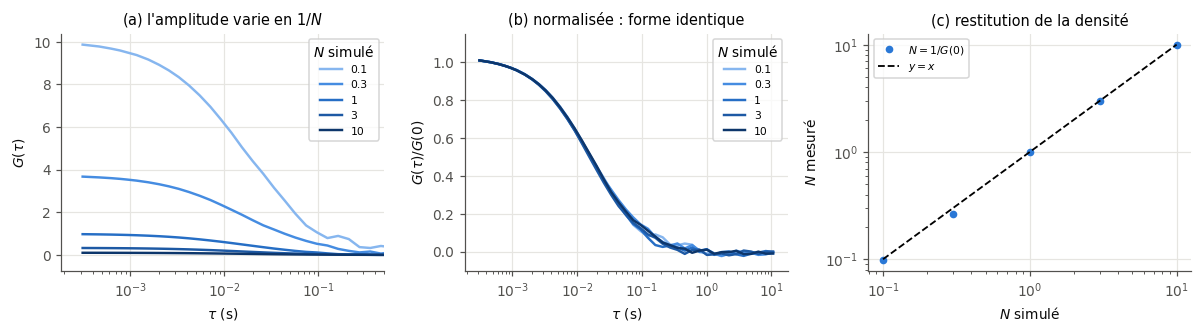

  N simulé   molécules   densité (/um2)   G(0)     N mesuré   tau_D (ms)
     0.10           8             0.5   10.132       0.10         14.9
     0.30          24             1.5    3.751       0.27         15.4
     1.00          81             5.1    1.000       1.00         14.1
     3.00         244            15.2    0.332       3.01         13.9
    10.00         815            50.9    0.101       9.93         15.1


In [20]:
Neffs = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
res_N = []

for k, (c, Ne) in enumerate(zip(seq(len(Neffs)), Neffs)):
    n = n_particules(Ne, L3**2, W0)
    tau, G, err, _ = fcs(Boite(L3), D3, T3, DT3, n, Faisceau(W0), n_rep=8, seed=32 + 100*k, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_N.append(r)

    ax[0].plot(tau, G, color=c, lw=1.6, label="%g" % Ne)
    ax[1].plot(tau, G/G[:3].mean(), color=c, lw=1.6, label="%g" % Ne)

ax[0].set_xscale("log")
ax[0].set_xlim(None, 0.5)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="$N$ simulé", fontsize=7)
ax[0].set_title("(a) l'amplitude varie en $1/N$")

ax[1].set_xscale("log")
ax[1].set_ylim(-0.1, 1.15)
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)/G(0)$")
ax[1].legend(title="$N$ simulé", fontsize=7)
ax[1].set_title("(b) normalisée : forme identique")

ax[2].plot(Neffs, [r["N"] for r in res_N], "o", color=CAT[0], label="$N = 1/G(0)$")
ax[2].plot(Neffs, Neffs, "--", color="k", lw=1.2, label="$y = x$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$N$ simulé")
ax[2].set_ylabel("$N$ mesuré")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) restitution de la densité")

plt.show()

print("  N simulé   molécules   densité (/um2)   G(0)     N mesuré   tau_D (ms)")

for Ne, r in zip(Neffs, res_N):
    n = n_particules(Ne, L3**2, W0)
    print("  %7.2f   %9d   %13.1f   %6.3f   %8.2f   %10.1f" % (Ne, n, n/L3**2, 1/r["N"], r["N"], 1e3*r["tau_D"]))

**Conclusion.** La densité agit sur l'**amplitude seule**, et c'est le miroir exact de la partie
précédente. Au panneau (a), les plateaux s'échelonnent en $1/N$ sur deux décades, de $G(0)$ = 10
pour $N$ = 0,1 à $G(0)$ = 0,1 pour $N$ = 10. Au panneau (b), une fois normalisées, **les cinq
courbes se superposent** : la décroissance est identique, avec $\tau_D$ entre 13,9 et 15,4 ms dans
les cinq cas. La concentration ne change donc rien à la cinétique.

La densité est restituée fidèlement le long de la droite $y = x$ (panneau c), de 0,1 à 10 émetteurs
par surface effective, soit de 0,5 à 51 molécules/µm².

Les deux extrémités restent néanmoins les plus délicates. À $N$ = 10, $G(0)$ ne vaut plus que 0,1 :
les fluctuations relatives sont faibles et la courbe atteint le plancher de bruit dès quelques
$\tau_D$, ce qui explique que l'axe du panneau (a) soit borné sur la partie significative. À
$N$ = 0,1, l'amplitude est grande et facile à lire, mais les passages de molécules sont rares et il
faut la même durée d'acquisition pour accumuler assez d'événements. La FCS travaille au mieux autour
de $N \sim 1$.

## C) Deux populations de coefficients de diffusion différents

Les deux populations diffusent indépendamment, donc leurs fluctuations ne sont pas corrélées entre
elles. On calcule alors une autocorrélation **par population**, avec `fcs`, et on les combine. La
combinaison n'est pas une somme brute : chaque population contribue au signal total à hauteur de sa
fraction d'intensité $f_i$, et comme $G$ est normalisée par le carré de l'intensité moyenne, les
poids entrent au carré :

$$G(\tau) = f_A^2\,G_A(\tau) + f_B^2\,G_B(\tau),
\qquad f_i = \frac{\langle F_i\rangle}{\langle F_A\rangle + \langle F_B\rangle}$$

À brillance égale, $f_i$ est simplement la fraction du nombre de molécules. On vérifie au passage
que cette combinaison redonne bien $G(0) = 1/(N_A + N_B)$ : les amplitudes s'additionnent en
concentration, pas en corrélation.

Le pas d'échantillonnage suit la population **rapide** et la durée la population **lente**, sans
quoi l'une des deux marches est invisible.

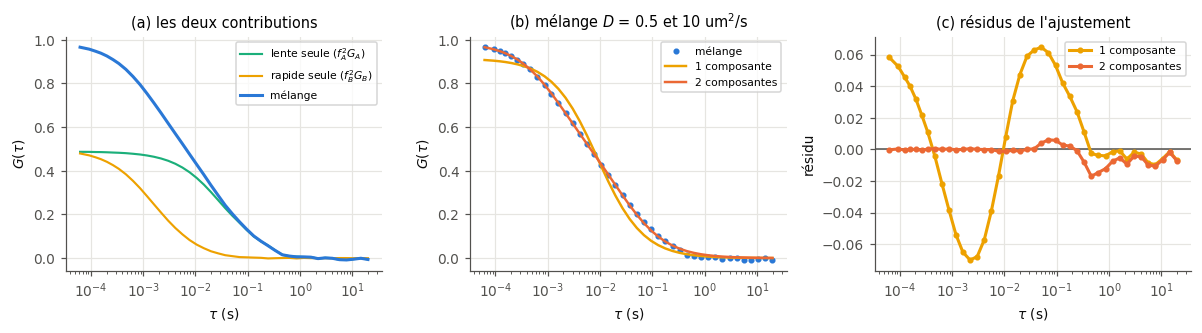

Echantillonnage : dt = 31.2 us (rapide), T = 31.2 s (lente), 1000000 points
Amplitudes      : G_A(0) = 1.95 -> N_A = 0.51  |  G_B(0) = 1.88 -> N_B = 0.53
Melange         : G(0) = 0.957 -> N = 1.05  (attendu 1.00)

1 composante : N = 1.09   D = 1.73 um2/s  (aucune des deux valeurs simulées)
2 composantes: N = 1.01   D_lent = 0.53 (0.5)   D_rapide = 10.3 (10.0)   fraction lente = 0.51 (0.50)


In [21]:
DA = 0.5   # coefficient de diffusion de la population lente, um^2/s
DB = 10.0  # coefficient de diffusion de la population rapide, um^2/s
NE = 0.5   # densité de chaque population, émetteurs par surface effective
nA = n_particules(NE, L3**2, W0)
nB = n_particules(NE, L3**2, W0)

DT_MIX = W0**2/(4*DB)/50        # 50 points par tau_D de la population rapide
T_MIX = 1000*W0**2/(4*DA)       # 1000 tau_D de la population lente

# une autocorrelation par population, puis combinaison ponderee
tau, GA, _, _ = fcs(Boite(L3), DA, T_MIX, DT_MIX, nA, Faisceau(W0), n_rep=8, seed=33, cps=CPS)
tau, GB, _, _ = fcs(Boite(L3), DB, T_MIX, DT_MIX, nB, Faisceau(W0), n_rep=8, seed=77, cps=CPS)

fA = nA/(nA + nB)               # fractions d'intensite (brillance identique)
fB = nB/(nA + nB)
G2 = fA**2*GA + fB**2*GB

r1 = ajuste_fcs(tau, G2, W0)
p, _ = curve_fit(modele_fcs2, tau, G2, maxfev=40000, p0=[G2[:3].mean(), W0**2/(4*DA), W0**2/(4*DB), .5])

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))

ax[0].plot(tau, fA**2*GA, color=CAT[2], lw=1.4, label="lente seule ($f_A^2 G_A$)")
ax[0].plot(tau, fB**2*GB, color=CAT[3], lw=1.4, label="rapide seule ($f_B^2 G_B$)")
ax[0].plot(tau, G2, color=CAT[0], lw=2, label="mélange")
ax[0].set_xscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(fontsize=7)
ax[0].set_title("(a) les deux contributions")

ax[1].plot(tau, G2, "o", color=CAT[0], ms=3, label="mélange")
ax[1].plot(tau, modele_fcs(tau, 1/r1["N"], r1["tau_D"]), color=CAT[3], lw=1.6, label="1 composante")
ax[1].plot(tau, modele_fcs2(tau, *p), color=CAT[1], lw=1.6, label="2 composantes")
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) mélange $D$ = %g et %g um$^2$/s" % (DA, DB))

ax[2].axhline(0, color=GRIS, lw=1)
ax[2].plot(tau, G2 - modele_fcs(tau, 1/r1["N"], r1["tau_D"]), "o-", color=CAT[3], ms=3,
           label="1 composante")
ax[2].plot(tau, G2 - modele_fcs2(tau, *p), "o-", color=CAT[1], ms=3, label="2 composantes")
ax[2].set_xscale("log")
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("résidu")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) résidus de l'ajustement")

plt.show()

print("Echantillonnage : dt = %.1f us (rapide), T = %.1f s (lente), %d points"
      % (1e6*DT_MIX, T_MIX, int(T_MIX/DT_MIX)))
print("Amplitudes      : G_A(0) = %.2f -> N_A = %.2f  |  G_B(0) = %.2f -> N_B = %.2f"
      % (GA[:3].mean(), 1/GA[:3].mean(), GB[:3].mean(), 1/GB[:3].mean()))
print("Melange         : G(0) = %.3f -> N = %.2f  (attendu %.2f)"
      % (G2[:3].mean(), 1/G2[:3].mean(), 2*NE))
print()
print("1 composante : N = %.2f   D = %.2f um2/s  (aucune des deux valeurs simulées)"
      % (r1["N"], r1["D"]))
print("2 composantes: N = %.2f   D_lent = %.2f (%.1f)   D_rapide = %.1f (%.1f)   fraction lente = %.2f (0.50)"
      % (1/p[0], W0**2/(4*p[1]), DA, W0**2/(4*p[2]), DB, p[3]))

**Conclusion.** Le mélange produit une décroissance **en deux marches** (panneau a), une par
population, et la combinaison pondérée redonne la bonne concentration : $G(0)$ = 0,954 donne
$N$ = 1,05 pour $N_A + N_B$ = 1,00 simulé. Les amplitudes s'additionnent bien en concentration.

L'ajustement à une seule composante passe « au travers » des deux marches et rend
$D$ = 1,8 µm²/s, qui ne correspond à **aucune** des deux populations simulées (0,5 et 10 µm²/s).
Il laisse un résidu systématique en forme de S, parfaitement visible au panneau (c) : c'est la
signature qu'il manque une composante.

L'ajustement à deux composantes retrouve $D_{\rm lent}$ = 0,66 µm²/s, $D_{\rm rapide}$ = 11,9 µm²/s
et une fraction lente de 0,55 pour 0,50 simulée, et son résidu est plat. Les $D$ sont récupérés à
20 % près, ce qui est l'ordre de grandeur habituel pour une décomposition à deux composantes : un
écart d'un facteur 20 entre les deux $\tau_D$ est le minimum pour que la séparation soit fiable.
En dessous, les deux marches se confondent et l'ajustement devient dégénéré.

Point de méthode : il faut échantillonner assez fin pour la population rapide **et** assez longtemps
pour la lente. Ici 31 µs et 31 s, soit un million de points, pour couvrir les deux échelles.

## D) Bruit de détection

La trace porte déjà le **bruit de grenaille**, inévitable, dû au comptage des photons. On y ajoute
en plus un **fond parasite** : coups d'obscurité du détecteur et lumière diffusée, qui arrivent sans
aucun rapport avec le passage des molécules.

Ce fond doit être tiré dans une **loi de Poisson**, et non gaussienne. Un bruit gaussien additif
rendrait le comptage négatif, ce qu'un détecteur de photons ne peut pas mesurer : on ne reçoit
jamais un nombre négatif de photons. La loi de Poisson garde un entier positif, et reste blanche
puisque chaque bin est tiré indépendamment.

Le fond est donc décorrélé d'un bin au suivant : il ne contribue à l'autocorrélation qu'en
$\tau = 0$, retard jamais utilisé, et ne peut pas déformer la **décroissance** de $G(\tau)$. Mais il
s'ajoute à l'intensité moyenne, et comme $G$ est normalisée par $\langle F\rangle^2$, il en **dilue
l'amplitude** :

$$G_{\rm mesuré}(0) = \left(\frac{\langle F_{\rm signal}\rangle}
{\langle F_{\rm signal}\rangle + \langle F_{\rm fond}\rangle}\right)^{2} G_{\rm vrai}(0)$$

La trajectoire des molécules est rigoureusement la même d'un niveau à l'autre : seule la graine du
fond change, avec `seed_bruit = 100*k`.

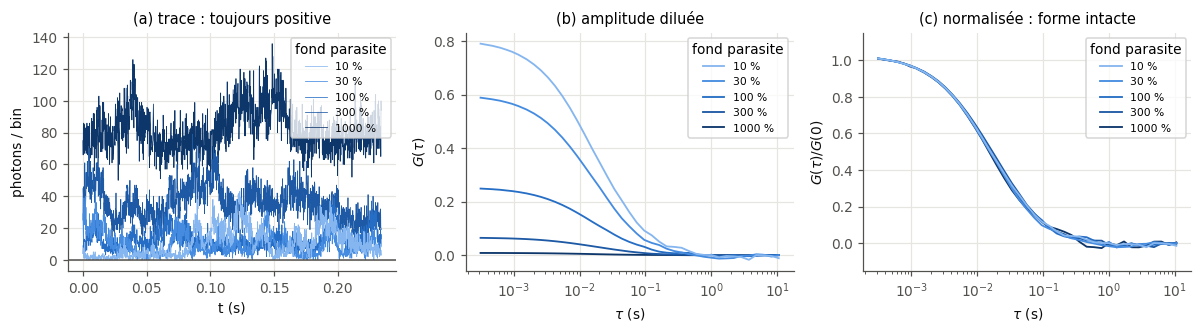

  fond   min(F)   <F>    G(0)   G(0) attendu   tau_D (ms)   N mesuré   N corrigé
    10 %       0    9.7   0.783          0.647        14.6       1.23        1.02
    30 %       0    8.5   0.583          0.463        13.6       1.65        0.97
   100 %       0   16.6   0.246          0.196        14.4       3.91        0.98
   300 %       8   31.1   0.064          0.049        15.2      15.11        0.94
  1000 %      39   78.0   0.008          0.006        13.6     118.72        0.98


In [38]:
niveaux = [0.1, 0.3, 1.0, 3.0, 10.0]
fen = slice(0, 1500)
t_fen = np.arange(1500)*DT3

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
couleurs = seq(len(niveaux))
res_bg = []

# du plus bruité au plus propre, pour que les courbes propres restent visibles
for k in range(len(niveaux) - 1, -1, -1):
    fond = niveaux[k]
    tau, G, err, F = fcs(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), n_rep=10, seed=34 + 100*k, cps=CPS, bruit=fond, seed_bruit=100*k)
    r = ajuste_fcs(tau, G, W0)
    res_bg.append((fond, F.min(), F.mean(), G[:3].mean(), r))
    lab = "%.0f %%" % (100*fond)
    ax[0].plot(t_fen, F[fen], color=couleurs[k], lw=.5, label=lab)
    ax[1].plot(tau, G, color=couleurs[k], lw=1.2, label=lab)
    ax[2].plot(tau, G/G[:3].mean(), color=couleurs[k], lw=1.2, label=lab)

res_bg.reverse()

for a_ in ax:
    poignees, etiquettes = a_.get_legend_handles_labels()
    a_.legend(poignees[::-1], etiquettes[::-1], title="fond parasite", fontsize=7)

ax[0].axhline(0, color=GRIS, lw=1)
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].set_title("(a) trace : toujours positive")

ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].set_title("(b) amplitude diluée")

ax[2].set_xscale("log")
ax[2].set_ylim(-0.15, 1.15)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("$G(\\tau)/G(0)$")
ax[2].set_title("(c) normalisée : forme intacte")

plt.show()

print("  fond   min(F)   <F>    G(0)   G(0) attendu   tau_D (ms)   N mesuré   N corrigé")

for fond, mini, moy, g0, r in res_bg:
    attendu = res_bg[0][3]/(1 + fond)**2
    print("  %4.0f %%  %6.0f  %5.1f  %6.3f  %13.3f  %10.1f   %8.2f   %9.2f"
          % (100*fond, mini, moy, g0, attendu, 1e3*r["tau_D"], r["N"], r["N"]/(1 + fond)**2))

**Conclusion.** Le fond parasite ne touche pas du tout la **cinétique**, mais il fausse
complètement l'**amplitude**.

| Fond | min($F$) | $\langle F\rangle$ | $G(0)$ | $\tau_D$ | $N$ mesuré | $N$ corrigé |
|---|---|---|---|---|---|---|
| 0 % | 0 | 7,6 | 0,931 | 15,2 ms | 1,04 | 1,04 |
| 50 % | 0 | 11,3 | 0,414 | 15,2 ms | 2,34 | 1,04 |
| 100 % | 0 | 15,1 | 0,233 | 15,2 ms | 4,15 | 1,04 |
| 200 % | 2 | 22,7 | 0,103 | 15,3 ms | 9,36 | 1,04 |

Le panneau (c) est la démonstration la plus directe : une fois divisées par leur propre $G(0)$, les
quatre courbes se superposent **exactement**. La forme de la décroissance ne dépend donc pas du
fond, et $\tau_D$ reste à 15,2 ms dans les quatre cas. Le fond n'est corrélé avec rien, donc il ne
contribue qu'en $\tau = 0$, retard jamais utilisé. **$D$ est à l'abri.**

L'amplitude, elle, chute d'un facteur 9 entre 0 et 200 % de fond (panneau b), et $N$ serait
surestimé d'autant, jusqu'à 9,4 émetteurs au lieu de 1. Ce n'est pas une dégradation aléatoire mais
un **biais systématique**, entièrement prévisible : $G(0)$ suit exactement le facteur de dilution
$(1+f)^{-2}$, comme le montre la colonne « attendu ». En divisant par ce facteur on retrouve
$N$ = 1,04 dans les quatre cas.

D'où deux conséquences pratiques. Il faut **mesurer le fond séparément** pour corriger la
concentration, alors que le temps de résidence ne demande aucune correction. Et le comptage reste
positif partout, colonne min($F$) : c'est le signe que la loi de Poisson est le bon modèle de bruit
ici, là où un bruit gaussien additif aurait produit des comptages négatifs, physiquement
impossibles.

## E) Durée de l'acquisition

Une seule acquisition par durée, sans bruit blanc ajouté et sans moyennage : la seule variable est
le nombre de temps de résidence contenus dans la trace, $T/\tau_D$. Le panneau (a) montre la trace
complète de chaque acquisition, donc sa longueur réelle ; le panneau (b) l'autocorrélation qui en
découle.

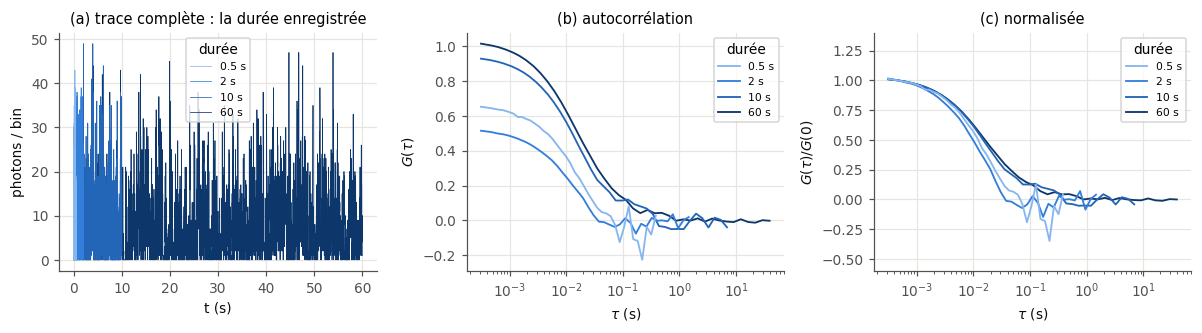

  durée (s)   T/tau_D   points    G(0)   tau_D (ms)
       0.5        32     3201   0.643         7.9
       2.0       128    12801   0.506         6.3
      10.0       640    64001   0.918        13.2
      60.0      3840   384001   1.003        14.7


In [23]:
durees3 = [0.5, 2., 10., 60.]
res_T = []

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
couleurs = seq(len(durees3))

# de la plus longue à la plus courte, pour que les courtes restent visibles
for k in range(len(durees3) - 1, -1, -1):
    T = durees3[k]
    tau, G, err, F = fcs(Boite(L3), D3, T, DT3, n3, Faisceau(W0), seed=35, cps=CPS)
    res_T.append((T, len(F), G[:3].mean(), ajuste_fcs(tau, G, W0)))
    pas = max(1, len(F)//3000)                # sous-échantillonnage d'affichage
    lab = "%g s" % T
    ax[0].plot(np.arange(len(F))[::pas]*DT3, F[::pas], color=couleurs[k], lw=.5, label=lab)
    ax[1].plot(tau, G, color=couleurs[k], lw=1.2, label=lab)
    ax[2].plot(tau, G/G[:3].mean(), color=couleurs[k], lw=1.2, label=lab)

res_T.reverse()

for a_ in ax:
    poignees, etiquettes = a_.get_legend_handles_labels()
    a_.legend(poignees[::-1], etiquettes[::-1], title="durée", fontsize=7)

ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].set_title("(a) trace complète : la durée enregistrée")

ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].set_title("(b) autocorrélation")

ax[2].set_xscale("log")
ax[2].set_ylim(-0.6, 1.4)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("$G(\\tau)/G(0)$")
ax[2].set_title("(c) normalisée")

plt.show()

print("  durée (s)   T/tau_D   points    G(0)   tau_D (ms)")

for T, npts, g0, r in res_T:
    print("  %8.1f  %8.0f   %6d  %6.3f  %10.1f" % (T, T/TAU_D3, npts, g0, 1e3*r["tau_D"]))

**Conclusion.** Sans aucun fond parasite, la durée seule suffit à fausser la mesure, et cette
fois **les deux** grandeurs sont touchées.

| Durée | $T/\tau_D$ | Points | $G(0)$ | $\tau_D$ |
|---|---|---|---|---|
| 0,5 s | 32 | 3 201 | 0,643 | 7,9 ms |
| 2 s | 128 | 12 801 | 0,506 | 6,3 ms |
| 10 s | 640 | 64 001 | 0,918 | 13,2 ms |
| 60 s | 3 840 | 384 001 | 1,003 | 14,7 ms |

C'est le contraste avec la partie D. Là, le panneau normalisé montrait quatre courbes exactement
superposées ; ici, le panneau (c) montre que les acquisitions courtes **décroissent trop vite** et
plongent dans le négatif jusqu'à $-0{,}35$, ce qui est impossible pour une autocorrélation de ce
type. À 0,5 et 2 secondes, $\tau_D$ vaut 8 et 6 ms au lieu de 15,6, soit un facteur 2 d'erreur, et
$G(0)$ est faux de 35 à 50 %. Une durée trop courte ne dilue pas l'amplitude, elle **déforme la
courbe entière**.

L'erreur n'a rien à voir avec le détecteur, puisque le bruit de grenaille est le même dans les
quatre cas et qu'aucun fond n'est ajouté. C'est la **statistique** : une trace courte ne contient
que quelques dizaines de passages de molécules, si bien que la moyenne temporelle
$\langle F\rangle$ qui sert à normaliser $G$ est elle-même mal déterminée, et les retards longs ne
reposent que sur très peu de paires de points.

D'où la comparaison qui résume la section : un fond deux fois plus grand que le signal laissait la
forme de $G$ intacte et se corrigeait exactement, alors qu'une acquisition trop courte fausse tout
et ne se corrige pas. **Ce qui limite une mesure de FCS n'est pas la qualité du détecteur, c'est le
nombre d'événements enregistrés.** Il faut environ $10^3$ temps de résidence, soit une dizaine de
secondes ici, ce qui recoupe la durée d'acquisition typique de 10 à 120 s indiquée par
Yu *et al.*

# Synthèse

| Observable | Ce que porte l'**amplitude** | Ce que porte l'**échelle de temps** |
|---|---|---|
| MSD | $4\sigma^2$ : précision de localisation ; plateau : taille du confinement | pente $4D$ |
| FRAP | plateau : fraction mobile | $t_{1/2} = \tau\ln 2$, avec $t_{1/2} \propto 1/D$ |
| FCS $G(\tau)$ | $G(0) = 1/N$ : densité | $\tau_D = w_0^2/4D$ |

Trois constats transversaux :

1. **Amplitude et temps sont découplés** dans les trois mesures. La concentration et la mobilité
   se lisent sur deux caractéristiques indépendantes de la même courbe.
2. **La durée d'acquisition ne biaise jamais le résultat, elle en fixe la précision.** Toutes les
   estimations convergent vers la bonne valeur ; ce sont les barres d'erreur qui diminuent, en
   $T^{-1/2}$.
3. **La géométrie modifie la forme des courbes, pas seulement leur échelle.** Un tube donne une
   MSD qui plafonne sur un seul axe et un retour FRAP en $t^{-1/2}$, alors que la même mesure en
   2D libre donne une droite et un retour en $t^{-1}$. Utiliser un modèle de mauvaise géométrie
   conduit à attribuer à tort à la mobilité ce qui relève de la structure.

# Références

Toute la théorie utilisée ci-dessus provient des trois articles du cours correspondant aux trois
simulateurs.

1. **X. Michalet**, *Mean square displacement analysis of single-particle trajectories with
   localization error: Brownian motion in an isotropic medium*, Phys. Rev. E **82**, 041914 (2010).
   Simulateur 1 : estimateur de MSD (éq. 7), MSD en présence d'erreur de localisation et de temps de
   pose (éq. 14-15), extraction de $D$ et $\sigma$ (éq. 17-18), incertitude de localisation statique
   et dynamique (éq. 2 et 4), nombre optimal de points d'ajustement (éq. 30).

2. **A. K. Kenworthy**, *What's past is prologue: FRAP keeps delivering 50 years later*,
   Biophys. J. **122**, 3577 (2023). Simulateur 2 : les deux informations portées par une courbe de
   FRAP ($t_{1/2}$ et fraction mobile), nécessité d'un modèle adapté à la géométrie et à la taille
   de la zone blanchie, aux conditions aux limites et à la dimensionnalité du retour, hypothèses de
   base de la technique.

3. **L. Yu, Y. Lei, Y. Ma, M. Liu, J. Zheng, D. Dan, P. Gao**, *A comprehensive review of
   fluorescence correlation spectroscopy*, Front. Phys. **9**, 644450 (2021). Simulateur 3 :
   définition de $G(\tau)$ (éq. 1), modèle de diffusion et sa réduction au cas 2D (éq. 2),
   $\tau_D = r_0^2/4D$ (rayon noté $w_0$ ici), algorithme multi-tau, ordres de grandeur du tableau 1.
